In [1]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
import matplotlib.pyplot as plt
import sympy
import random
from ase.io import read

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
from sympy import symbols, simplify, sin, expand
import sympy as sp
import pymc as pm
import arviz as az

In [24]:
atoms_train = read("/home/paolo/Na_dataset/train_Na_new.xyz", index=":")
atoms_test = read("/home/paolo/Na_dataset/test_Na_new.xyz", index=":")

In [4]:
data_train = pd.concat(
    [pd.DataFrame([a.info for a in atoms_train]),
     pd.DataFrame({'cub_root_V': [a.get_volume()**(1/3) for a in atoms_train]})],
    axis=1
)
data_test = pd.concat(
    [pd.DataFrame([a.info for a in atoms_test]),
     pd.DataFrame({'cub_root_V': [a.get_volume()**(1/3) for a in atoms_test]})],
    axis=1
)

In [5]:
data_train

,Ea,B,N,O,F,Na,Al,Si,P,S,...,face-area-max,face-area-avg,face-area-min,face-area-count,pockets-per-ion,pockets-per-volume,paths-per-ion,paths-per-volume,poly_dist_avg_fixed,cub_root_V
0,0.365113,0.000000,0.0,0.631387,0.000000,0.127737,0.000000,0.000000,0.171533,0.000000,...,10.973040,2.521378,2.554994e-06,24.784055,5.371429,0.046887,45.342857,0.395793,0.385197,25.218719
1,0.425024,0.000000,0.0,0.467925,0.000000,0.184906,0.000000,0.000000,0.135849,0.000000,...,11.777366,2.837638,8.278834e-07,29.008265,1.173469,0.011507,5.484694,0.053782,0.375974,27.138803
2,0.274638,0.113043,0.0,0.000000,0.000000,0.208696,0.108696,0.000000,0.000000,0.304348,...,15.033404,3.383426,2.368494e-11,39.474009,2.583333,0.021100,14.566667,0.118978,0.080752,30.858072
3,0.324737,0.000000,0.0,0.000000,0.000000,0.101124,0.000000,0.243446,0.033708,0.621723,...,12.877547,3.444336,5.345359e-06,40.587672,8.425926,0.032273,51.564815,0.197504,0.116010,30.436900
4,0.345059,0.000000,0.0,0.407692,0.000000,0.219231,0.000000,0.000000,0.161538,0.000000,...,15.090982,3.165906,4.092372e-09,35.067899,2.105263,0.021466,13.359649,0.136222,0.363843,28.172671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,0.321759,0.000000,0.0,0.000000,0.000000,0.241935,0.000000,0.000000,0.161290,0.451613,...,12.864103,3.268545,4.741584e-07,37.803003,1.360784,0.012972,5.980392,0.057011,0.091131,29.906856
1037,0.389788,0.000000,0.0,0.380711,0.106599,0.335025,0.177665,0.000000,0.000000,0.000000,...,8.761876,1.934795,1.569696e-06,12.466122,0.335859,0.008334,2.255051,0.055958,0.317510,25.176614
1038,0.393305,0.250000,0.0,0.500000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,...,8.829005,1.864119,7.645468e-07,13.897762,0.412000,0.008600,1.924000,0.040160,0.368284,22.879676
1039,0.335168,0.000000,0.0,0.417969,0.000000,0.187500,0.000000,0.000000,0.027344,0.000000,...,13.544451,2.987695,7.102955e-06,32.194261,3.026042,0.029022,16.453125,0.157799,0.301010,27.152839


In [17]:
def initialize_units(df_iniz, med_flag = False):
    '''
    Zeta standardization of the dimensionful features
    '''
    df = (df_iniz - df_iniz.mean()) / df_iniz.std()
    kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
    return {
        "E" : np.array(df['Ea'], dtype = 'float'),
        "cub_root_V" : np.array(df['cub_root_V'], dtype = 'float'),
        
        # Density in g/cm^3
        "density": np.array(df['density'], dtype='float'),
        # Average Atomic Volume
        "AAV": np.array(df['AAV'], dtype='float'),
        # Volume per anion
        "VPA": np.array(df['VPA'], dtype='float'),
        # -Na-Na (are just the Na-Na distances)
        "Na-Na": np.array(df['Na-Na'], dtype='float'),
        "Na-Na-max": np.array(df['Na-Na-max'], dtype='float'),
        "Na-Na-avg": np.array(df['Na-Na-avg'], dtype='float'),
        # -bottleneck (free distance available for a Na⁺ ion to pass through the narrowest part of a diffusion pathway formed by surrounding framework atoms (typically O²⁻, S²⁻, or halides))
        "bottleneck_min": np.array(df['bottleneck_min'], dtype='float'),
        "bottleneck_avg": np.array(df['bottleneck_avg'], dtype='float'),
        # -face-area   (area of the shared face between two neighboring Voronoi polyhedra corresponding to adjacent Na sites it represents the cross-sectional area available for Na⁺ migration between those sites)
        "face-area-max": np.array(df['face-area-max'], dtype='float'),
        "face-area-avg": np.array(df['face-area-avg'], dtype='float'),
        "face-area-min": np.array(df['face-area-min'], dtype='float'),
        # -pockets  (free-volume region in the crystal structure where a Na⁺ ion can reside with relatively low energy, typically corresponding to a stable or metastable Na site)
        "pockets-per-volume": np.array(df['pockets-per-volume'], dtype='float'),
        # -paths  (connected sequence of pockets linked by Voronoi faces and constrained by bottlenecks, forming a continuous route that allows Na⁺ ions to move through the crystal lattice)
        "paths-per-volume": np.array(df['paths-per-volume'], dtype='float')
    }

## SISSO initialization

In [42]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize_units(data_train)
T = 300
lnDvsE = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data_train['Ea']))], 
    "E_T": data_train['Ea']/(kb*T),
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data_train['PF'],
    "VPA": data['VPA'],
    "NBI": data_train['NBI'],
    "SBI": data_train['SBI'],
    "RBI": data_train['RBI'],
    "WE": data_train['weighted_electronegativity'],
    "B": data_train['B'],
    "N": data_train['N'],
    "S": data_train['S'],
    "O": data_train['O'],
    "F": data_train['F'],
    "Na": data_train['Na'],
    "Al": data_train['Al'],
    "Si": data_train['Si'],
    "P": data_train['P'],
    "Cl": data_train['Cl'],
    "Ge": data_train['Ge'],
    "Br": data_train['Br'],
    "I": data_train['I'],

    # Volume
    "cub_root_V" : data['cub_root_V'],
    
    # Na–Na distances
    "Na-Na": data['Na-Na'],
    "Na-Na-max": data['Na-Na-max'],
    "Na-Na-avg": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min": data['bottleneck_min'],
    "bottleneck_avg": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data_train['poly_dist_max'],
    "poly_dist_std": data_train['poly_dist_std'],
    "poly_dist_avg": data_train['poly_dist_avg'],
    "poly_dist_avg_fixed": data_train['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max": data['face-area-max'],
    "face-area-avg": data['face-area-avg'],
    "face-area-min": data['face-area-min'],
    "face-area-count": data_train['face-area-count'],

    # Pockets
    "pockets-per-ion": data_train['pockets-per-ion'],
    "pockets-per-volume": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data_train['paths-per-ion'],
    "paths-per-volume": data['paths-per-volume'],

    # Target
    "ln_D": data_train['logD']
})    

In [8]:
n_feat = 40
lnDvsE.to_csv(f"/home/paolo/Thesis/Na/data/desc_dim/Na_lndiff{n_feat}_temp300_unitless3.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/desc_dim/Na_lndiff{n_feat}_temp300_unitless3.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [9]:
# Try the fit with the exact functional form
rung = 1
desc_dim = 4
Diff_json = {
    'data_file': data_file,
     'property_key': 'ln_D',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/desc_dim/lndiff{n_feat}_{rung}_{desc_dim}_unitless3.json", "w"), indent=4)

In [ ]:
# Rung=1 desc_dim=3 Features=40 'E_T': E/(kb*T), 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA, 'NBI': NBI, 'SBI': SBI,  'RBI': RBI, 'WE': WE, 
        # 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 'Ge': Ge, 'Br': Br, 'I': I, 'cub_root_V': V^(1/3),
        # "Na-Na": data['Na-Na'], "Na-Na-max": data['Na-Na-max'], "Na-Na-avg": data['Na-Na-avg'], "bottleneck_min": data['bottleneck_min'], "bottleneck_avg": data['bottleneck_avg'],
        # "poly_dist_max": data['poly_dist_max'], "poly_dist_std": data['poly_dist_std'], "poly_dist_avg": data['poly_dist_avg'], "poly_dist_avg_fixed": data['poly_dist_avg_fixed'],
        # "face-area-max": data['face-area-max'], "face-area-avg": data['face-area-avg'], "face-area-min": data['face-area-min'], "face-area-count": data['face-area-count'],
        # "pockets-per-ion": data['pockets-per-ion'], "pockets-per-volume": data['pockets-per-volume'],
        # "paths-per-ion": data['paths-per-ion'], "paths-per-volume": data['paths-per-volume'],
# time input_parsing: 0.047971 s
# Time to generate feat space: 0.0246587 s
# Projection time: 0.002091 s
# Time to get best features on rank : 0.0001027 s
# |---Complete final combination/selection from all ranks: 0.0007093 s
# Time for SIS: 0.0039328 s
# Time for l0-norm: 0.0101639 s
# Projection time: 0.0076434 s
# Time to get best features on rank : 8.25e-05 s
# |---Complete final combination/selection from all ranks: 0.0003108 s
# Time for SIS: 0.0096912 s
# Time for l0-norm: 0.0051573 s
# Projection time: 0.0051165 s
# Time to get best features on rank : 7.77e-05 s
# |---Complete final combination/selection from all ranks: 0.0002989 s
# Time for SIS: 0.0073937 s
# Time for l0-norm: 0.0234609 s
# Projection time: 0.0048969 s
# Time to get best features on rank : 7.89e-05 s
# |---Complete final combination/selection from all ranks: 0.0003133 s
# Time for SIS: 0.0078289 s
# Time for l0-norm: 0.551339 s
# Train RMSE: 0.504806 Unitless
# c0 + a0 * (AAV - E_T)

# Train RMSE: 0.352047 Unitless
# c0 + a0 * (Al + O) + a1 * (face-area-avg - E_T)

# Train RMSE: 0.292567 Unitless
# c0 + a0 * (P + B) + a1 * (O - NBI) + a2 * (face-area-avg - E_T)

# Train RMSE: 0.258747 Unitless
# c0 + a0 * (P * S) + a1 * (poly_dist_std + B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)


## Formula Extraction

In [9]:
def extract_dd4(ms = 10, rung=1, feat = 40):
    '''Extract the formulas and the values of the parameters from the SISSO output for desc_dim=4 and Rung = 1'''
    dd = 4
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    a3_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/desc_dim/models_lndiff{feat}_{rung}_{dd}_unitless/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            a3_i = parts[6].rstrip(',')
            c0_i = parts[7].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            a3_list.append(a3_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, a3_list, c0_list)

In [7]:
raw_formulas, a0_list, a1_list, a2_list, a3_list, c0_list = extract_dd4()

In [10]:
# 10 best formulas
raw_formulas

['c0 + a0 * (P * S) + a1 * (poly_dist_std + B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)',
 'c0 + a0 * (P * S) + a1 * (Al - B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)',
 'c0 + a0 * (P / poly_dist_avg_fixed) + a1 * (poly_dist_std + B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)',
 'c0 + a0 * (P * S) + a1 * (poly_dist_std * B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)',
 'c0 + a0 * (P - Al) + a1 * (poly_dist_std + B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)',
 'c0 + a0 * (poly_dist_std * B) + a1 * (P - Al) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)',
 'c0 + a0 * (P / NBI) + a1 * (poly_dist_std + B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)',
 'c0 + a0 * (poly_dist_std - Al) + a1 * (P + B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)',
 'c0 + a0 * (P * S) + a1 * (poly_dist_max * B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)',
 'c0 + a0 * (poly_dist_max * B) + a1 * (P - Al) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)']

In [11]:
def sanitize(expr):
    '''
    Fix Descriptor names
    '''
    return (
        expr
        .replace('Na-Na-avg', 'Na_Na_avg')
        .replace('Na-Na-max', 'Na_Na_max')
        .replace('Na-Na', 'Na_Na')
        .replace('face-area-avg', 'face_area_avg')
        .replace('face-area-max', 'face_area_max')
        .replace('face-area-min', 'face_area_min')
        .replace('face-area-count', 'face_area_count')
        .replace('cub_root_V', 'cub_root_V')
        .replace('pockets-per-ion', 'pockets_per_ion')
        .replace('pockets-per-volume', 'pockets_per_volume')
        .replace('paths-per-ion', 'paths_per_ion')
        .replace('paths-per-volume', 'paths_per_volume')
    )

In [12]:
formulas = [sanitize(f) for f in raw_formulas]
formulas

['c0 + a0 * (P * S) + a1 * (poly_dist_std + B) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)',
 'c0 + a0 * (P * S) + a1 * (Al - B) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)',
 'c0 + a0 * (P / poly_dist_avg_fixed) + a1 * (poly_dist_std + B) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)',
 'c0 + a0 * (P * S) + a1 * (poly_dist_std * B) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)',
 'c0 + a0 * (P - Al) + a1 * (poly_dist_std + B) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)',
 'c0 + a0 * (poly_dist_std * B) + a1 * (P - Al) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)',
 'c0 + a0 * (P / NBI) + a1 * (poly_dist_std + B) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)',
 'c0 + a0 * (poly_dist_std - Al) + a1 * (P + B) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)',
 'c0 + a0 * (P * S) + a1 * (poly_dist_max * B) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)',
 'c0 + a0 * (poly_dist_max * B) + a1 * (P - Al) + a2 * (O - NBI) + a3 * (face_area_avg - E_T)']

In [13]:
a0 = np.array(a0_list, dtype=float)
a1 = np.array(a1_list, dtype=float)
a2 = np.array(a2_list, dtype=float)
a3 = np.array(a3_list, dtype=float)
c0 = np.array(c0_list, dtype=float)

In [14]:
# Coefficients are separated from function blocks to be later added as distributions
a0_sym, a1_sym, a2_sym, a3_sym, c0_sym = sp.symbols('a0 a1 a2 a3 c0')
symbols = sp.symbols(
    '''
    E_T B N O F Na Al Si P S Cl Ge Br I
    density AAV PF SBI RBI VPA NBI WE cub_root_V
    bottleneck_min bottleneck_avg
    poly_dist_avg poly_dist_max poly_dist_std poly_dist_avg_fixed
    Na_Na Na_Na_max Na_Na_avg
    face_area_max face_area_avg face_area_min face_area_count
    pockets_per_ion pockets_per_volume
    paths_per_ion paths_per_volume
    '''
)

locals_dict = {s.name: s for s in symbols}
# convert strings to sympy expressions
sympy_exprs = [sp.sympify(f, locals=locals_dict) for f in formulas]

pruned = []
# Prunes the coefficients that will be added later as distributions
for f in sympy_exprs:
    row = [
        sp.simplify(f.coeff(a0_sym)),
        sp.simplify(f.coeff(a1_sym)),
        sp.simplify(f.coeff(a2_sym)),
        sp.simplify(f.coeff(a3_sym)),
    ]
    pruned.append(row)

pruned

[[P*S, B + poly_dist_std, -NBI + O, -E_T + face_area_avg],
 [P*S, Al - B, -NBI + O, -E_T + face_area_avg],
 [P/poly_dist_avg_fixed, B + poly_dist_std, -NBI + O, -E_T + face_area_avg],
 [P*S, B*poly_dist_std, -NBI + O, -E_T + face_area_avg],
 [-Al + P, B + poly_dist_std, -NBI + O, -E_T + face_area_avg],
 [B*poly_dist_std, -Al + P, -NBI + O, -E_T + face_area_avg],
 [P/NBI, B + poly_dist_std, -NBI + O, -E_T + face_area_avg],
 [-Al + poly_dist_std, B + P, -NBI + O, -E_T + face_area_avg],
 [P*S, B*poly_dist_max, -NBI + O, -E_T + face_area_avg],
 [B*poly_dist_max, -Al + P, -NBI + O, -E_T + face_area_avg]]

In [15]:
vars_ = [
    locals_dict[k] for k in [
        "E_T", 'B', 'N', 'S', 'O', 'F', 'Na', 'Al', 'Si', 'P', 'Cl', 'Ge', 'Br', 'I', 'density', 'AAV', 'PF', 'NBI', 'SBI', 'RBI', 'VPA', 'WE', 'cub_root_V', 
        'Na_Na', 'Na_Na_max', 'Na_Na_avg', 'bottleneck_min', 'bottleneck_avg', 'poly_dist_max', 'poly_dist_std', 'poly_dist_avg', 'poly_dist_avg_fixed',
        'face_area_max', 'face_area_avg', 'face_area_min', 'face_area_count', 
        'pockets_per_ion', 'pockets_per_volume', 'paths_per_ion', 'paths_per_volume',
    ]
]
# Feature functions
Phi = [
    sp.lambdify(vars_, row, modules="numpy")
    for row in pruned
]

In [22]:
data = initialize_units(data_train)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
# X contains the train values of the subformulas of the best models
X = np.array([
    phi(
        data_train['Ea']/(kb*T),
        data_train['B'],
        data_train['N'],
        data_train['S'],
        data_train['O'],
        data_train['F'],
        data_train['Na'],
        data_train['Al'],
        data_train['Si'],
        data_train['P'],
        data_train['Cl'],
        data_train['Ge'],
        data_train['Br'],
        data_train['I'],
        
        data['density'],
        data['AAV'],
        data_train['PF'],
        data_train['NBI'],
        data_train['SBI'],
        data_train['RBI'],
        data['VPA'],
        data_train['weighted_electronegativity'],
        
        
        # Volume
        data['cub_root_V'],
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data_train['poly_dist_max'],
        data_train['poly_dist_std'],
        data_train['poly_dist_avg'],
        data_train['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data_train['face-area-count'],
        
        # Pockets
        data_train['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data_train['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [21]:
data2 = initialize_units(data_test)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
# X_test contains the test values of the subformulas of the best models
X_test = np.array([
    phi(
        data_test['Ea']/(kb*T),
        data_test['B'],
        data_test['N'],
        data_test['S'],
        data_test['O'],
        data_test['F'],
        data_test['Na'],
        data_test['Al'],
        data_test['Si'],
        data_test['P'],
        data_test['Cl'],
        data_test['Ge'],
        data_test['Br'],
        data_test['I'],
        
        data2['density'],
        data2['AAV'],
        data_test['PF'],
        data_test['NBI'],
        data_test['SBI'],
        data_test['RBI'],
        data2['VPA'],
        data_test['weighted_electronegativity'],
        
        
        # Volume
        data2['cub_root_V'],
        
        # Na–Na distances
        data2['Na-Na'],
        data2['Na-Na-max'],
        data2['Na-Na-avg'],
        
        # Bottleneck descriptors
        data2['bottleneck_min'],
        data2['bottleneck_avg'],
        
        # Polyhedral distortion
        data_test['poly_dist_max'],
        data_test['poly_dist_std'],
        data_test['poly_dist_avg'],
        data_test['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data2['face-area-max'],
        data2['face-area-avg'],
        data2['face-area-min'],
        data_test['face-area-count'],
        
        # Pockets
        data_test['pockets-per-ion'],
        data2['pockets-per-volume'],
        
        # Paths
        data_test['paths-per-ion'],
        data2['paths-per-volume'],
    )
    for phi in Phi
])

In [20]:
# 10 formulas with 4 subformulas each for each of the 1041 entries of the dataset
X.shape, X_test.shape

((10, 4, 1041), (10, 4, 261))

In [20]:
np.max(c0), np.max(a0), np.max(a1), np.max(a2), np.max(a3)

(np.float64(-12.43071839828398),
 np.float64(21.97148755394599),
 np.float64(24.84986765931797),
 np.float64(-2.429453491513268),
 np.float64(0.674075794923286))

In [50]:
# Sequential Monte-Carlo
traces1 = []
ppcs = []
models_stored = 10
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = X[i, :, :]
        f_test = X_test[i, :, :]

        # Uninformative Priors
        c0_coeff = pm.Normal("c0", mu=c0[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0[i], sigma=10)
        a1_coeff = pm.Normal("a1", mu=a1[i], sigma=10)
        a2_coeff = pm.Normal("a2", mu=a2[i], sigma=10)
        a3_coeff = pm.Normal("a3", mu=a3[i], sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :] + a3_coeff * f[3, :]

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data_train['logD'])

        # Sample from posterior
        trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)

        # Posterior predictive for the TEST set:
        # Create a new RV for test predictions using the same parameters.
        mu_test = pm.Deterministic("mu_test", c0_coeff + a0_coeff * f_test[0, :] + a1_coeff * f_test[1, :] + a2_coeff * f_test[2, :] + a3_coeff * f_test[3, :])
        y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)
        
        ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y_test"],
        random_seed=123
    )
        traces1.append(trace)
        ppcs.append(ppc)
        idata = trace.posterior
        az.to_netcdf(idata, f"trace_model_{i}.nc")
        az.to_netcdf(ppc, f"pp_model_{i}.nc")

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

In [51]:
c0[0], a0[0], a1[0], a2[0], a3[0]

(np.float64(-13.05003282802374),
 np.float64(6.506759313602232),
 np.float64(2.579860758331584),
 np.float64(-2.894205639476978),
 np.float64(0.6631587065836255))

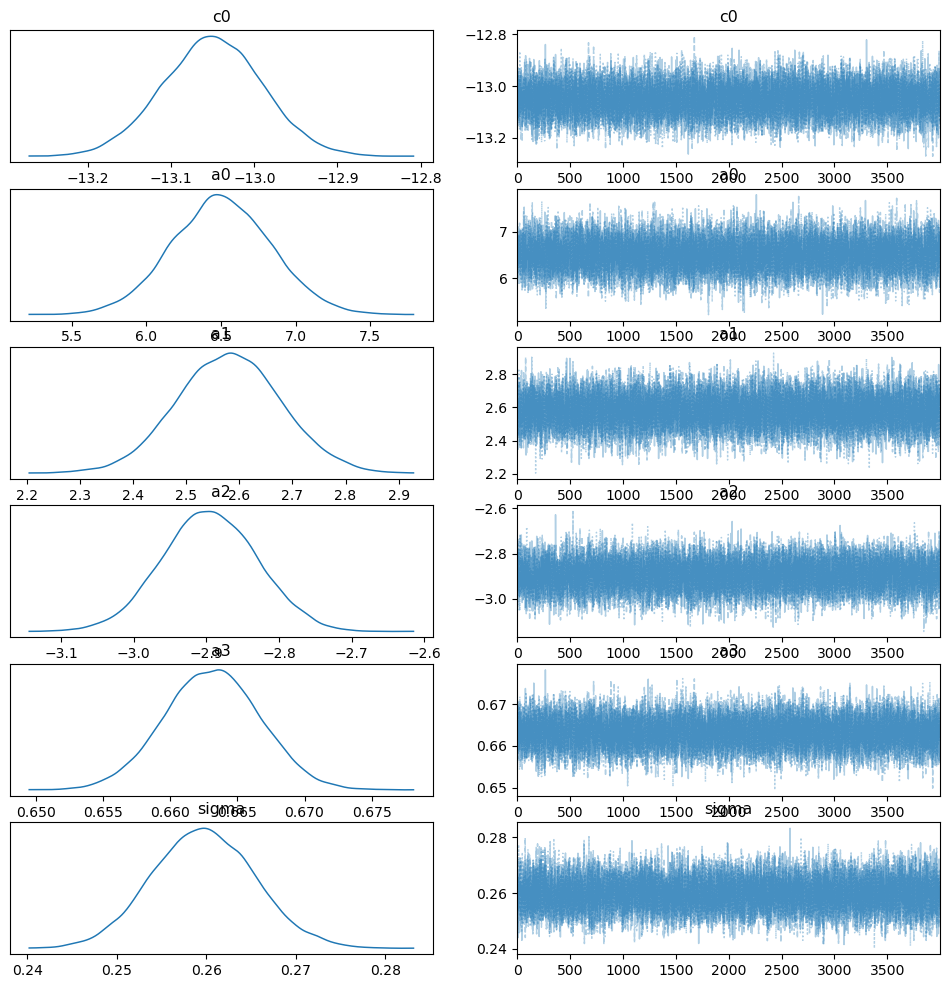

In [52]:
az.plot_trace(traces1[0], combined=True);

In [53]:
# log marginal likelihood for model 0: 6 chains and 11 draws per chain
traces1[1].sample_stats["log_marginal_likelihood"].values 

array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, np.float64(-135.8421224568762)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, np.float64(-135.71218872758888)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, np.float64(-135.4388616828763)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, np.float64(-133.7590528299276)]], dtype=object)

In [54]:
# Computes the Marginal Likelihood
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces1[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[-108.45147496 -107.78060305 -107.5330386  -105.87596951]
[-135.84212246 -135.71218873 -135.43886168 -133.75905283]
[-146.50505617 -147.30829089 -148.37176052 -151.41402823]
[-140.75020321 -142.05286374 -140.82988676 -140.13021371]
[-149.37511108 -149.92918285 -148.04741241 -147.31811776]
[-149.96552215 -151.28855102 -148.94335429 -148.00192899]
[-157.44731045 -157.20342015 -158.9572084  -161.70315301]
[-158.11087929 -158.49277851 -161.08682485 -155.10544763]
[-153.98517627 -153.61598905 -153.93567135 -152.57169339]
[-159.53145597 -160.0981917  -160.90532889 -161.95574019]


In [55]:
log_marginal_likelihoods

[np.float64(-107.41027153065184),
 np.float64(-135.18805642431727),
 np.float64(-148.3997839510876),
 np.float64(-140.94079185284687),
 np.float64(-148.6674560234165),
 np.float64(-149.5498391142536),
 np.float64(-158.82777300230623),
 np.float64(-158.19898257068542),
 np.float64(-153.5271325155074),
 np.float64(-160.62267918985154)]

In [56]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml 

(np.float64(-107.41027153065184), np.int64(0))

In [57]:
# Computes the marginal likelihood ratios between the given model and the benchmark, Bayes' Factors
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(1.0),
 np.float64(8.63497930761616e-13),
 np.float64(1.5793592920830079e-18),
 np.float64(2.7408170591429365e-15),
 np.float64(1.2084604343175369e-18),
 np.float64(5.000556385209262e-19),
 np.float64(4.6737215832165574e-23),
 np.float64(8.764821024526574e-23),
 np.float64(9.369183644040617e-21),
 np.float64(7.76506302143639e-24)]

In [58]:
# Bayesian Ranking
np.argsort(ml_diff)

array([9, 6, 7, 8, 5, 4, 2, 3, 1, 0])

## Tempering

In [19]:
# Values of the Temperature Weight
beta = np.array([1/8, 1/4, 1/2])
beta

array([0.125, 0.25 , 0.5  ])

In [20]:
traces_temp = []
models_stored = 10
for i in range(models_stored):
    traces_i = []
    for j in beta:
        with pm.Model() as model:
            # Select the i-th column
            f = X[i, :, :]
            f_test = X_test[i, :, :]
    
            # Priors weakly informative
            c0_coeff = pm.Normal("c0", mu=c0[i], sigma=5)
            a0_coeff = pm.Normal("a0", mu=a0[i], sigma=5)
            a1_coeff = pm.Normal("a1", mu=a1[i], sigma=5)
            a2_coeff = pm.Normal("a2", mu=a2[i], sigma=5)
            a3_coeff = pm.Normal("a3", mu=a3[i], sigma=5)
            sigma = pm.HalfNormal("sigma", sigma=2)
    
            # Linear parametrization
            mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :] + a3_coeff * f[3, :]
    
    
            # Standard log-likelihood
            dist = pm.Normal.dist(mu=mu, sigma=sigma)
            logp = pm.logp(dist, data_train['logD'])

            # Tempered likelihood --> log (y| theta) = sum_n log(y_n|theta)
            pm.Potential("tempered_likelihood", j * logp.sum())
    
            # Sample from posterior
            # Sequential montecarlo
            trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)
            #trace = pm.sample()
            traces_i.append(trace)
    traces_temp.append(traces_i)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

In [21]:
marginal_likelihoods_temp = []
log_marginal_likelihoods_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        log_ml_raw = traces_temp[i][j].sample_stats["log_marginal_likelihood"].values
    
        # Flatten possible nested lists and cast to floats
        flattened = []
        for row in log_ml_raw.ravel():
            # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
            if isinstance(row, (list, tuple, np.ndarray)):
                flattened.extend(row)
            # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
            else:
                flattened.append(row)
        # This ensures that everything inside flattened is a single scalar number, not a list or array.
        log_ml_temp = np.array(flattened, dtype=float)
        # Checks that the entry is effectively a number
        log_ml_temp = log_ml_temp[~np.isnan(log_ml_temp)]
        print(log_ml_temp)
        # Computes the mean
        mean_log_ml_temp = np.mean(log_ml_temp)
        log_marginal_likelihoods_temp.append(mean_log_ml_temp)

[-33.60536632 -34.13664131 -34.17430469 -34.73172499]
[-44.44711273 -45.28670147 -44.46288387 -44.56174833]
[-64.76507426 -64.81471117 -64.24135321 -62.52350603]
[-38.04906995 -37.54411384 -37.1256918  -38.24043174]
[-53.06229784 -52.01011157 -51.66213933 -51.66755095]
[-78.13397593 -78.19315285 -77.79274032 -77.57409968]
[-43.54788923 -41.89727486 -41.88661769 -41.50191629]
[-59.57915836 -57.36710173 -56.39214046 -56.46556088]
[-87.26442759 -84.0827038  -85.44994196 -85.35710484]
[-36.07736218 -35.56675714 -35.27153989 -35.68109755]
[-50.77917381 -51.41239084 -52.24539855 -50.79715952]
[-79.75659399 -80.63548244 -79.90128433 -79.88530693]
[-40.44839021 -41.22934163 -40.34393606 -40.15483426]
[-56.4373401  -56.68504539 -56.19053976 -55.32822017]
[-85.40702937 -85.29315721 -84.93247806 -84.28802889]
[-39.36670649 -38.08889519 -38.06200887 -38.69897324]
[-54.77402041 -54.90260725 -54.90097127 -54.04224474]
[-85.09226282 -84.78938391 -85.71112864 -84.196468  ]
[-41.69699657 -42.26879835 -

In [22]:
log_marginal_likelihoods_temp = np.array(log_marginal_likelihoods_temp).reshape(models_stored, len(beta))

In [23]:
# For each value of beta (comlumn) finds the representative with the highest marginal likelihood
for j in range(len(beta)):
    print(np.argmax(log_marginal_likelihoods_temp[:,j]))

0
0
0


In [24]:
ml_diff_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        # log_marginal_likelihoods_temp[np.argmax(marginal_likelihoods_temp[:,j]), j] --> log_marg_likelihood of the benchmark for that value of beta
        # e.g. if j=1 --> np.argmax(marginal_likelihoods_temp[:,j]) = (1,1) --> log_marginal_likelihoods_temp[1, 1]
        ml_diff_temp.append(np.exp(-(log_marginal_likelihoods_temp[np.argmax(log_marginal_likelihoods_temp[:,j]), j] - log_marginal_likelihoods_temp[i,j])))

In [25]:
ml_diff_temp = np.array(ml_diff_temp).reshape(models_stored, len(beta))
ml_diff_temp.T # Each row corresponds to the ml difference computed with the same value of beta for the different models

array([[1.00000000e+00, 2.79366032e-02, 3.20247894e-04, 2.26009134e-01,
        1.69153951e-03, 1.23742618e-02, 4.44564236e-04, 4.80053179e-04,
        1.57333848e-02, 1.60819276e-03],
       [1.00000000e+00, 6.04618232e-04, 2.86948279e-06, 1.33487306e-03,
        1.04315598e-05, 4.70006411e-05, 7.16827268e-07, 9.09849751e-07,
        2.86679091e-05, 2.78125360e-06],
       [1.00000000e+00, 9.78415875e-07, 4.82334443e-10, 1.17302971e-07,
        8.43035361e-10, 8.71199885e-10, 5.81741590e-12, 7.31072510e-12,
        1.44961892e-10, 3.70312313e-12]])

In [26]:
# Models' Indices corresponding to the entries sorted in ascending order for beta = 1/8, 1/4, 1/2
np.argsort(ml_diff_temp.T)

array([[2, 6, 7, 9, 4, 5, 8, 1, 3, 0],
       [6, 7, 9, 2, 4, 8, 5, 1, 3, 0],
       [9, 6, 7, 8, 2, 4, 5, 3, 1, 0]])

In [20]:
ordering = np.vstack([
       [2, 4, 6, 7, 9, 1, 5, 0, 8, 3],
       [2, 4, 6, 7, 9, 1, 5, 8, 0, 3],
       [2, 6, 7, 4, 9, 8, 5, 1, 0, 3],
       [2, 6, 7, 9, 4, 5, 8, 1, 3, 0],
       [6, 7, 9, 2, 4, 8, 5, 1, 3, 0],
       [9, 6, 7, 8, 2, 4, 5, 3, 1, 0],  
       [9, 6, 7, 8, 5, 4, 2, 3, 1, 0]])[:, ::-1]
ordering

array([[3, 8, 0, 5, 1, 9, 7, 6, 4, 2],
       [3, 0, 8, 5, 1, 9, 7, 6, 4, 2],
       [3, 0, 1, 5, 8, 9, 4, 7, 6, 2],
       [0, 3, 1, 8, 5, 4, 9, 7, 6, 2],
       [0, 3, 1, 5, 8, 4, 2, 9, 7, 6],
       [0, 1, 3, 5, 4, 2, 8, 7, 6, 9],
       [0, 1, 3, 2, 4, 5, 8, 7, 6, 9]])

<Figure size 1800x1800 with 0 Axes>

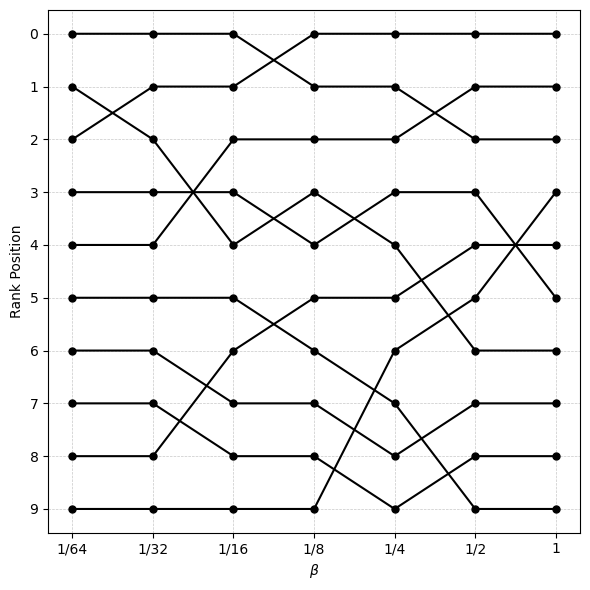

In [58]:
plt.figure(figsize=(6, 6), dpi=300)
steps = range(ordering.shape[0])
values = range(10)

plt.figure(figsize=(6,6))

for v in values:
    positions = [np.where(ordering[i] == v)[0][0] for i in steps]
    plt.plot(steps, positions, marker='o', markersize = 5, label=str(v), color = 'black')

plt.gca().invert_yaxis()
plt.xticks(steps, [r'1/64', r'1/32', r'1/16', r'1/8', r'1/4', r'1/2', r'1'])
plt.yticks([0,1,2,3,4,5,6,7,8,9])
plt.ylabel("Rank Position")
plt.xlabel(r"$\beta$")
#plt.title("Rank changes across vectors")

#plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
#plt.savefig('tempering_v1.pdf')
plt.show()

In [17]:
ordering_halved = np.vstack([
       [2, 6, 7, 9, 4, 5, 8, 1, 3, 0],
       [6, 7, 9, 2, 4, 8, 5, 1, 3, 0],
       [9, 6, 7, 8, 2, 4, 5, 3, 1, 0],  
       [9, 6, 7, 8, 5, 4, 2, 3, 1, 0]])[:, ::-1]

<Figure size 1800x1800 with 0 Axes>

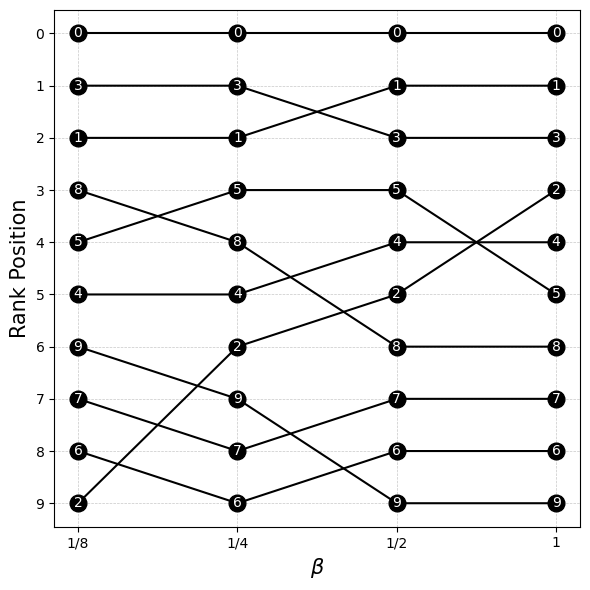

In [18]:
plt.figure(figsize=(6, 6), dpi=300)

steps = range(ordering_halved.shape[0])
values = range(10)

plt.figure(figsize=(6,6))

for v in values:
    positions = [np.where(ordering_halved[i] == v)[0][0] for i in steps]
    plt.plot(steps, positions, marker='o', markersize = 12, color='black')

    # Add labels inside markers
    for x, y in zip(steps, positions):
        plt.text(x, y, str(v),
                 ha='center', va='center',
                 fontsize=10, color='white')

plt.gca().invert_yaxis()
plt.xticks(steps, [ r'1/8', r'1/4', r'1/2', r'1'])
plt.yticks([0,1,2,3,4,5,6,7,8,9])
plt.ylabel("Rank Position", fontsize = 15)
plt.xlabel(r"$\beta$", fontsize = 15)

ax = plt.gca()
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

#plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()

plt.savefig('tempering_v2_halved.pdf')
plt.show()

## Best Model

In [18]:
# Montecarlo posterior values
files = [f"/home/paolo/Thesis/Na/mc_desc_dim_norm_lnD_dd4/trace_model_{i}.nc" for i in range(10)]
traces_list = [az.from_netcdf(f) for f in files]
traces1 = traces_list

In [19]:
# Posterior Parameters values
c0_post = []
a0_post = []
a1_post = []
a2_post = []
a3_post = []
models_stored = 10
for m in range(models_stored):
    c0_post.append(np.mean(traces1[m].posterior['c0'].values.flatten()))
    a0_post.append(np.mean(traces1[m].posterior['a0'].values.flatten()))
    a1_post.append(np.mean(traces1[m].posterior['a1'].values.flatten()))
    a2_post.append(np.mean(traces1[m].posterior['a2'].values.flatten()))
    a3_post.append(np.mean(traces1[m].posterior['a3'].values.flatten()))

In [20]:
c0_post[1], a0_post[1], a1_post[1], a2_post[1], a3_post[1]

(np.float64(-12.430610883975703),
 np.float64(5.3188559121709),
 np.float64(-1.6881245692369642),
 np.float64(-2.429861003663438),
 np.float64(0.667750964918994))

In [21]:
# Posterior Parameters standard deviation
c0_post_std = []
a0_post_std = []
a1_post_std = []
a2_post_std = []
a3_post_std = []
for m in range(models_stored):
    c0_post_std.append(np.std(traces1[m].posterior['c0'].values.flatten()))
    a0_post_std.append(np.std(traces1[m].posterior['a0'].values.flatten()))
    a1_post_std.append(np.std(traces1[m].posterior['a1'].values.flatten()))
    a2_post_std.append(np.std(traces1[m].posterior['a2'].values.flatten()))
    a3_post_std.append(np.std(traces1[m].posterior['a3'].values.flatten()))
c0_post_std, a0_post_std

([np.float64(0.06004867322609788),
  np.float64(0.06128224835234925),
  np.float64(0.0627727448308331),
  np.float64(0.06165544137503187),
  np.float64(0.06383800361314917),
  np.float64(0.06265886847690155),
  np.float64(0.06360458551503058),
  np.float64(0.06248675001292002),
  np.float64(0.06163408388842783),
  np.float64(0.06256359552497581)],
 [np.float64(0.3337389617049595),
  np.float64(0.33505525788629964),
  np.float64(0.017423865119627915),
  np.float64(0.33927650717527785),
  np.float64(0.07551149373636759),
  np.float64(1.0196449002343002),
  np.float64(0.07298602950070314),
  np.float64(0.09489272928641702),
  np.float64(0.3445388152563155),
  np.float64(0.2115022706936553)])

In [22]:
X.shape, X_test.shape

((10, 4, 1041), (10, 4, 261))

In [23]:
X_all = np.concatenate((X, X_test), axis=2)
X_all.shape

(10, 4, 1302)

In [24]:
data_all = np.concatenate((np.array(data_train['logD']), np.array(data_test['logD'])))

In [25]:
# Posterior Predictions 
y_post = []
y_post_test = []
y_post_all = []
for m in range(models_stored):
    y_post.append(np.array(c0_post[m]) + X[m, 0, :] * np.array(a0_post[m]) + X[m, 1, :] * np.array(a1_post[m]) + X[m, 2, :] * np.array(a2_post[m]) + X[m, 3, :] * np.array(a3_post[m]))
    y_post_test.append(np.array(c0_post[m]) + X_test[m, 0, :] * np.array(a0_post[m]) + X_test[m, 1, :] * np.array(a1_post[m]) + X_test[m, 2, :] * np.array(a2_post[m]) + X_test[m, 3, :] * np.array(a3_post[m]))
    y_post_all.append(np.array(c0_post[m]) + X_all[m, 0, :] * np.array(a0_post[m]) + X_all[m, 1, :] * np.array(a1_post[m]) + X_all[m, 2, :] * np.array(a2_post[m]) + X_all[m, 3, :] * np.array(a3_post[m]))

In [26]:
y_post = np.array(y_post).T
y_post_test = np.array(y_post_test).T
y_post_all = np.array(y_post_all).T
y_post.shape

(1041, 10)

In [27]:
# Training Dataset Ground Truths
y_obs = np.tile(data_train['logD'], (10,1)).T
y_obs

array([[-22.44947812, -22.44947812, -22.44947812, ..., -22.44947812,
        -22.44947812, -22.44947812],
       [-22.98888401, -22.98888401, -22.98888401, ..., -22.98888401,
        -22.98888401, -22.98888401],
       [-17.55271247, -17.55271247, -17.55271247, ..., -17.55271247,
        -17.55271247, -17.55271247],
       ...,
       [-22.68866241, -22.68866241, -22.68866241, ..., -22.68866241,
        -22.68866241, -22.68866241],
       [-20.02651   , -20.02651   , -20.02651   , ..., -20.02651   ,
        -20.02651   , -20.02651   ],
       [-24.39240447, -24.39240447, -24.39240447, ..., -24.39240447,
        -24.39240447, -24.39240447]], shape=(1041, 10))

In [28]:
# train RMSE
RMSE_train = np.sqrt(np.mean((y_obs - y_post)**2, axis = 0))
RMSE_train

array([0.25874726, 0.26522764, 0.26694171, 0.26828978, 0.26844369,
       0.26978203, 0.27091382, 0.27097722, 0.27111072, 0.27189711])

In [28]:
# train R^2
from sklearn.metrics import r2_score

r2_score(y_obs.T[0], y_post.T[0]), r2_score(y_obs.T[1], y_post.T[1])

(0.9820173706343707, 0.9811053334307978)

In [29]:
# Test Dataset Ground Truths
y_obs_test = np.tile(data_test['logD'], (10,1)).T

In [30]:
# test RMSE
RMSE_test = np.sqrt(np.mean((y_obs_test - y_post_test)**2, axis = 0))
RMSE_test

array([0.28788243, 0.27280164, 0.2936114 , 0.27916704, 0.28310531,
       0.27662498, 0.30023269, 0.2903249 , 0.28247127, 0.27875374])

In [31]:
# test R^2
r2_score(y_obs_test.T[0], y_post_test.T[0]), r2_score(y_obs_test.T[1], y_post_test.T[1])

(0.9773149692285967, 0.9796294386986825)

In [32]:
# all Dataset Ground Truths
y_obs_all = np.tile(data_all, (10,1)).T

In [33]:
# all daset RMSE
np.sqrt(np.mean((y_obs_all - y_post_all)**2, axis = 0))

array([0.2648447 , 0.26676316, 0.2724972 , 0.2705053 , 0.27144624,
       0.27116761, 0.27703987, 0.27496479, 0.27342589, 0.27328538])

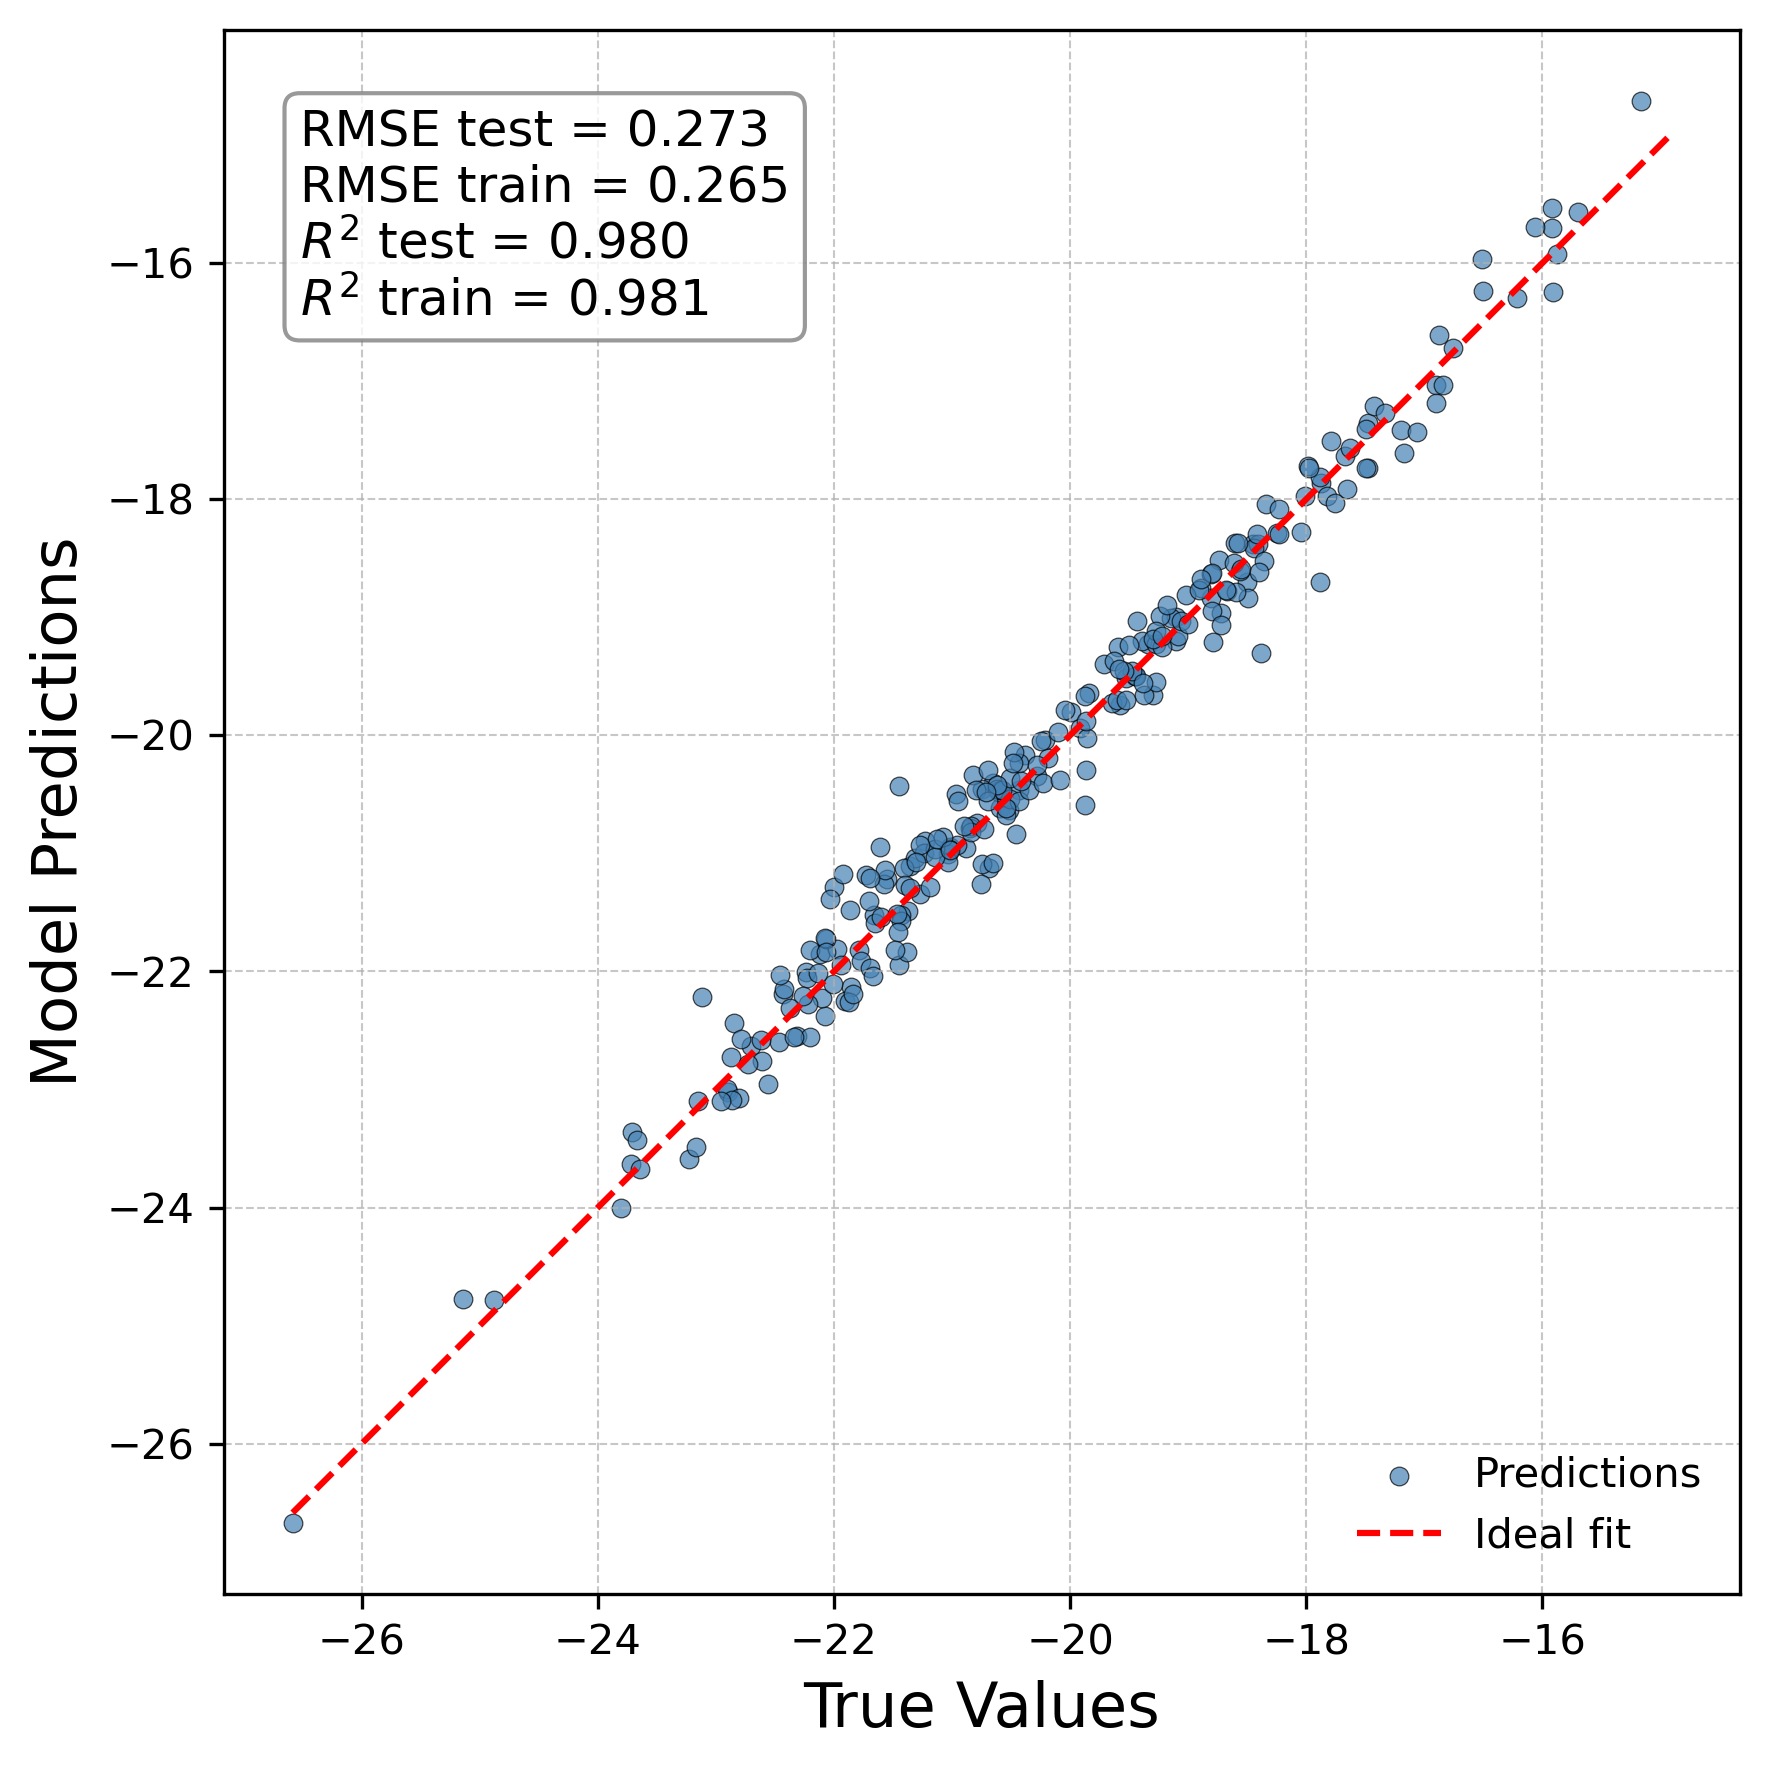

In [37]:
plt.figure(figsize=(6, 6), dpi=300)

# Scatter plot 
plt.scatter(
    data_test['logD'],
    y_post_test.T[1],
    s=20,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.3,
    color='steelblue',
    label='Predictions'
)

# Identity line (perfect prediction)
min_val = min(data_test['logD'].min(), y_post.T[1].min())
max_val = max(data_test['logD'].max(), y_post.T[1].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Ideal fit'
)


plt.xlabel('True Values', fontsize=15)
plt.ylabel('Model Predictions', fontsize=15)


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


textstr = f'RMSE test = {RMSE_test[1]:.3f}\nRMSE train = {RMSE_train[1]:.3f}\n$R^2$ test = {r2_score(y_obs_test.T[1], y_post_test.T[1]):.3f}\n$R^2$ train = {r2_score(y_obs.T[1], y_post.T[1]):.3f}'

plt.text(
    0.05, 0.95, textstr,             # position in axes coordinates
    transform=plt.gca().transAxes,   # use relative positioning (0–1)
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8,
        edgecolor='gray'
    )
)


plt.gca().set_aspect('equal', adjustable='box')

# Legend
plt.legend(frameon=False, fontsize=10)


plt.tight_layout()

#plt.savefig('best_model.pdf')

plt.show()

## Gradient Test

In [ ]:
'c0 + a0 * (P * S) + a1 * (Al - B) + a2 * (O - NBI) + a3 * (face-area-avg - E_T)'

In [29]:
def grad(best_fct, ex_fct):
    '''
    Function percentual change by exchanging features
    '''
    delta_y = np.abs(best_fct - ex_fct)
    return(np.mean(delta_y/y_obs.T[0]))

In [30]:
best_fct = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
best_fct

array([[-22.21677046, -23.02253254, -17.76992514, ..., -23.06636848,
        -20.42608914, -24.21659463]], shape=(1, 1041))

In [59]:
y_obs.T[0] 

array([-22.44947812, -22.98888401, -17.55271247, ..., -22.68866241,
       -20.02651   , -24.39240447], shape=(1041,))

In [134]:
# Exchange Al and P 
Al_P = np.array([c0_post[1] + a0_post[1] * data_train['Al'] * data_train['S'] + a1_post[1] * (data_train['P'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, Al_P)

np.float64(-0.011514273772901281)

In [133]:
# Exchange Al with Si
Al__Si = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Si'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, Al__Si)

np.float64(-0.0066539684208921385)

In [135]:
# Exchange Al with Ge
Al__Ge = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Ge'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, Al__Ge)

np.float64(-0.0065176731195178755)

In [136]:
# Exchange Al with P
Al__P = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['P'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, Al__P)

np.float64(-0.006122683733935055)

In [137]:
# Exchange Al with B
Al__B = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['B'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, Al__B)

np.float64(-0.0067970761175512135)

In [43]:
# Exchange face-area-avg with face-area-max 
Avg_Max = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-max'] - data_train['Ea']/(kb*T))])
grad(best_fct, Avg_Max)

np.float64(-0.015647325716891407)

In [45]:
# Exchange face-area-avg with face-area-min
Avg_Min = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-min'] - data_train['Ea']/(kb*T))])
grad(best_fct, Avg_Min)

np.float64(-0.030564489242379724)

In [47]:
# Exchange face-area-avg with face-area-min
Avg_count = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data_train['face-area-count'] - data_train['Ea']/(kb*T))])
grad(best_fct, Avg_count)

np.float64(-1.0527509889916657)

In [130]:
# Exchange O and S 
O_S = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['O'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['S'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, O_S)

np.float64(-0.05244691308923594)

In [ ]:
# O = 3,44

In [129]:
# Exchange O with F 3,98
O__F = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['F'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, O__F)

np.float64(-0.021895918234410346)

In [127]:
# Exchange O with Cl 3,16
O__Cl = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['Cl'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, O__Cl)

np.float64(-0.022812980033593958)

In [128]:
# Exchange O with N 3,04
O__N = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['N'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, O__N)

np.float64(-0.021750078977564802)

In [126]:
# Exchange O with Br 2,96
O__Br = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['Br'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, O__Br)

np.float64(-0.02320047441162254)

In [125]:
# Exchange O with I 2,66
O__I = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['I'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, O__I)

np.float64(-0.023284474131343123)

In [124]:
# Exchange O with S 2,58
O__S = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['S'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, O__S)

np.float64(-0.0480391074915966)

In [31]:
# Exchange S with O
S__O = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['O'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, S__O)

np.float64(-0.004407805597639334)

In [32]:
# Exchange S with N
S__N = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['N'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, S__N)

np.float64(-0.002951807744931384)

In [34]:
# Exchange S with F
S__F = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['F'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, S__F)

np.float64(-0.002938585413667205)

In [35]:
# Exchange S with Cl
S__Cl = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['Cl'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, S__Cl)

np.float64(-0.0029280468559649796)

In [36]:
# Exchange S with Br
S__Br = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['Br'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, S__Br)

np.float64(-0.0028800149951274663)

In [37]:
# Exchange S with I
S__I = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['I'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, S__I)

np.float64(-0.002825049667320649)

In [38]:
P__B = np.array([c0_post[1] + a0_post[1] * data_train['B'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, P__B)

np.float64(-0.005227094348860477)

In [40]:
P__Al = np.array([c0_post[1] + a0_post[1] * data_train['Al'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, P__Al)

np.float64(-0.005391590038966229)

In [41]:
P__Si = np.array([c0_post[1] + a0_post[1] * data_train['Si'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, P__Si)

np.float64(-0.005943406686030044)

In [42]:
P__Ge = np.array([c0_post[1] + a0_post[1] * data_train['Ge'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['NBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, P__Ge)

np.float64(-0.00540942373215691)

In [49]:
NBI__SBI = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['SBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, NBI__SBI)

np.float64(-0.03892404156977361)

In [50]:
NBI__RBI = np.array([c0_post[1] + a0_post[1] * data_train['P'] * data_train['S'] + a1_post[1] * (data_train['Al'] - data_train['B']) + a2_post[1] * (data_train['O'] - data_train['RBI']) 
          + a3_post[1] * (data['face-area-avg'] - data_train['Ea']/(kb*T))])
grad(best_fct, NBI__RBI)

np.float64(-0.37680938250691465)

## Ensemble Calibration

In [38]:
np.random.seed(10)
c0_samples_list = []
a0_samples_list = []
a1_samples_list = []
a2_samples_list = []
a3_samples_list = []
sigma_samples_list = []
models_stored = 10
for m in range(models_stored):
# Draws 200 samples of the parameters from the posterior distribution
    c0_samples_list.append(np.random.choice(traces1[m].posterior['c0'].values.flatten(), size=200, replace=True))
    a0_samples_list.append(np.random.choice(traces1[m].posterior['a0'].values.flatten(), size=200, replace=True))
    a1_samples_list.append(np.random.choice(traces1[m].posterior['a1'].values.flatten(), size=200, replace=True))
    a2_samples_list.append(np.random.choice(traces1[m].posterior['a2'].values.flatten(), size=200, replace=True))
    a3_samples_list.append(np.random.choice(traces1[m].posterior['a3'].values.flatten(), size=200, replace=True))
    sigma_samples_list.append(np.random.choice(traces1[m].posterior['sigma'].values.flatten(), size=200, replace=True))
c0_samples = np.array(c0_samples_list).T
a0_samples = np.array(a0_samples_list).T
a1_samples = np.array(a1_samples_list).T
a2_samples = np.array(a2_samples_list).T
a3_samples = np.array(a3_samples_list).T
sigma_samples = np.array(sigma_samples_list).T

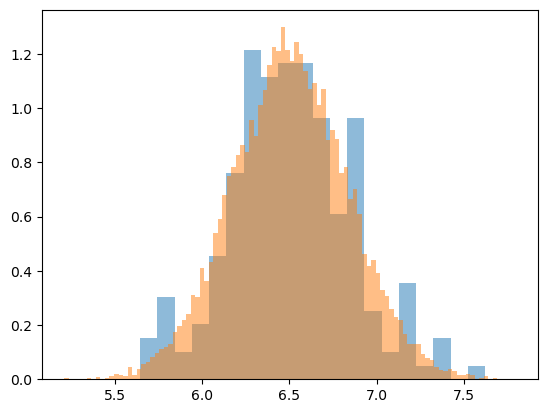

In [39]:
plt.hist(np.array(a0_samples.T[0]), alpha = 0.5, bins = 20, density = True)
plt.hist(traces1[0].posterior['a0'].values.flatten(), bins = 100, alpha = 0.5, density = True)
plt.show()

In [40]:
# Ensemble empirical mean
inputs = 1041
y_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the mean over the ensemble for each of the 1041 points for each of the 10 formulas
        y_emp[i, m] = np.mean(c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m] + X[m, 3, i] * a3_samples[:,m])
# Empirical mean over the models
y_emp

array([[-22.56984353, -22.2126207 , -22.46717196, ..., -22.10737663,
        -22.44079001, -22.15857034],
       [-23.15955104, -23.01875481, -23.06159359, ..., -22.8584851 ,
        -23.1856782 , -22.96159696],
       [-17.63063199, -17.76692011, -17.63263441, ..., -17.69864512,
        -17.64187379, -17.67405121],
       ...,
       [-23.11500439, -23.06411407, -23.1291805 , ..., -23.17315107,
        -22.89211449, -22.94631356],
       [-20.41432847, -20.42242093, -20.40475734, ..., -20.38380191,
        -20.59467555, -20.47105505],
       [-24.26845116, -24.21302916, -24.26458132, ..., -24.28064517,
        -24.33895363, -24.31769593]], shape=(1041, 10))

In [41]:
# Ensemble empirical variance
inputs = 1041
var_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the variance over the ensemble for each of the 1041 points for each of the 10 formulas
        #var_emp[i, m] = np.var((c0_samples + Phi[i, m] * a0_samples + sigma_samples - y_emp[i,m])**2), ddof = 1)
        # Assuming decorrelation between noise and parameters
        var_emp[i, m] = 1/(200-1) * np.sum((c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m] + X[m, 3, i] * a3_samples[:,m] - y_emp[i,m])**2 
                                           + sigma_samples[:,m]**2)
# Empirical variance over the models
var_emp

array([[0.07399151, 0.07768628, 0.07833036, ..., 0.08297801, 0.08359543,
        0.0811923 ],
       [0.07485641, 0.07841686, 0.07917724, ..., 0.08425451, 0.08460919,
        0.08173535],
       [0.0739158 , 0.07695587, 0.07800542, ..., 0.08142785, 0.08202414,
        0.08009972],
       ...,
       [0.07597715, 0.07878136, 0.0800545 , ..., 0.08458987, 0.08605432,
        0.08152747],
       [0.07389902, 0.07710858, 0.07798638, ..., 0.08243078, 0.08261962,
        0.0803351 ],
       [0.07587993, 0.07946143, 0.08019962, ..., 0.08592486, 0.08603336,
        0.08246256]], shape=(1041, 10))

In [42]:
y_obs = np.tile(data_train['logD'], (10,1)).T
y_obs

array([[-22.44947812, -22.44947812, -22.44947812, ..., -22.44947812,
        -22.44947812, -22.44947812],
       [-22.98888401, -22.98888401, -22.98888401, ..., -22.98888401,
        -22.98888401, -22.98888401],
       [-17.55271247, -17.55271247, -17.55271247, ..., -17.55271247,
        -17.55271247, -17.55271247],
       ...,
       [-22.68866241, -22.68866241, -22.68866241, ..., -22.68866241,
        -22.68866241, -22.68866241],
       [-20.02651   , -20.02651   , -20.02651   , ..., -20.02651   ,
        -20.02651   , -20.02651   ],
       [-24.39240447, -24.39240447, -24.39240447, ..., -24.39240447,
        -24.39240447, -24.39240447]], shape=(1041, 10))

In [43]:
# Columnwise mean of the given vector, i.e. mean over the features
R = np.mean((y_obs - y_emp)**2/var_emp, axis = 0)
R

array([0.9024791 , 0.90670218, 0.90829922, 0.89767077, 0.90044198,
       0.89027171, 0.88962079, 0.88826673, 0.88651164, 0.91627474])

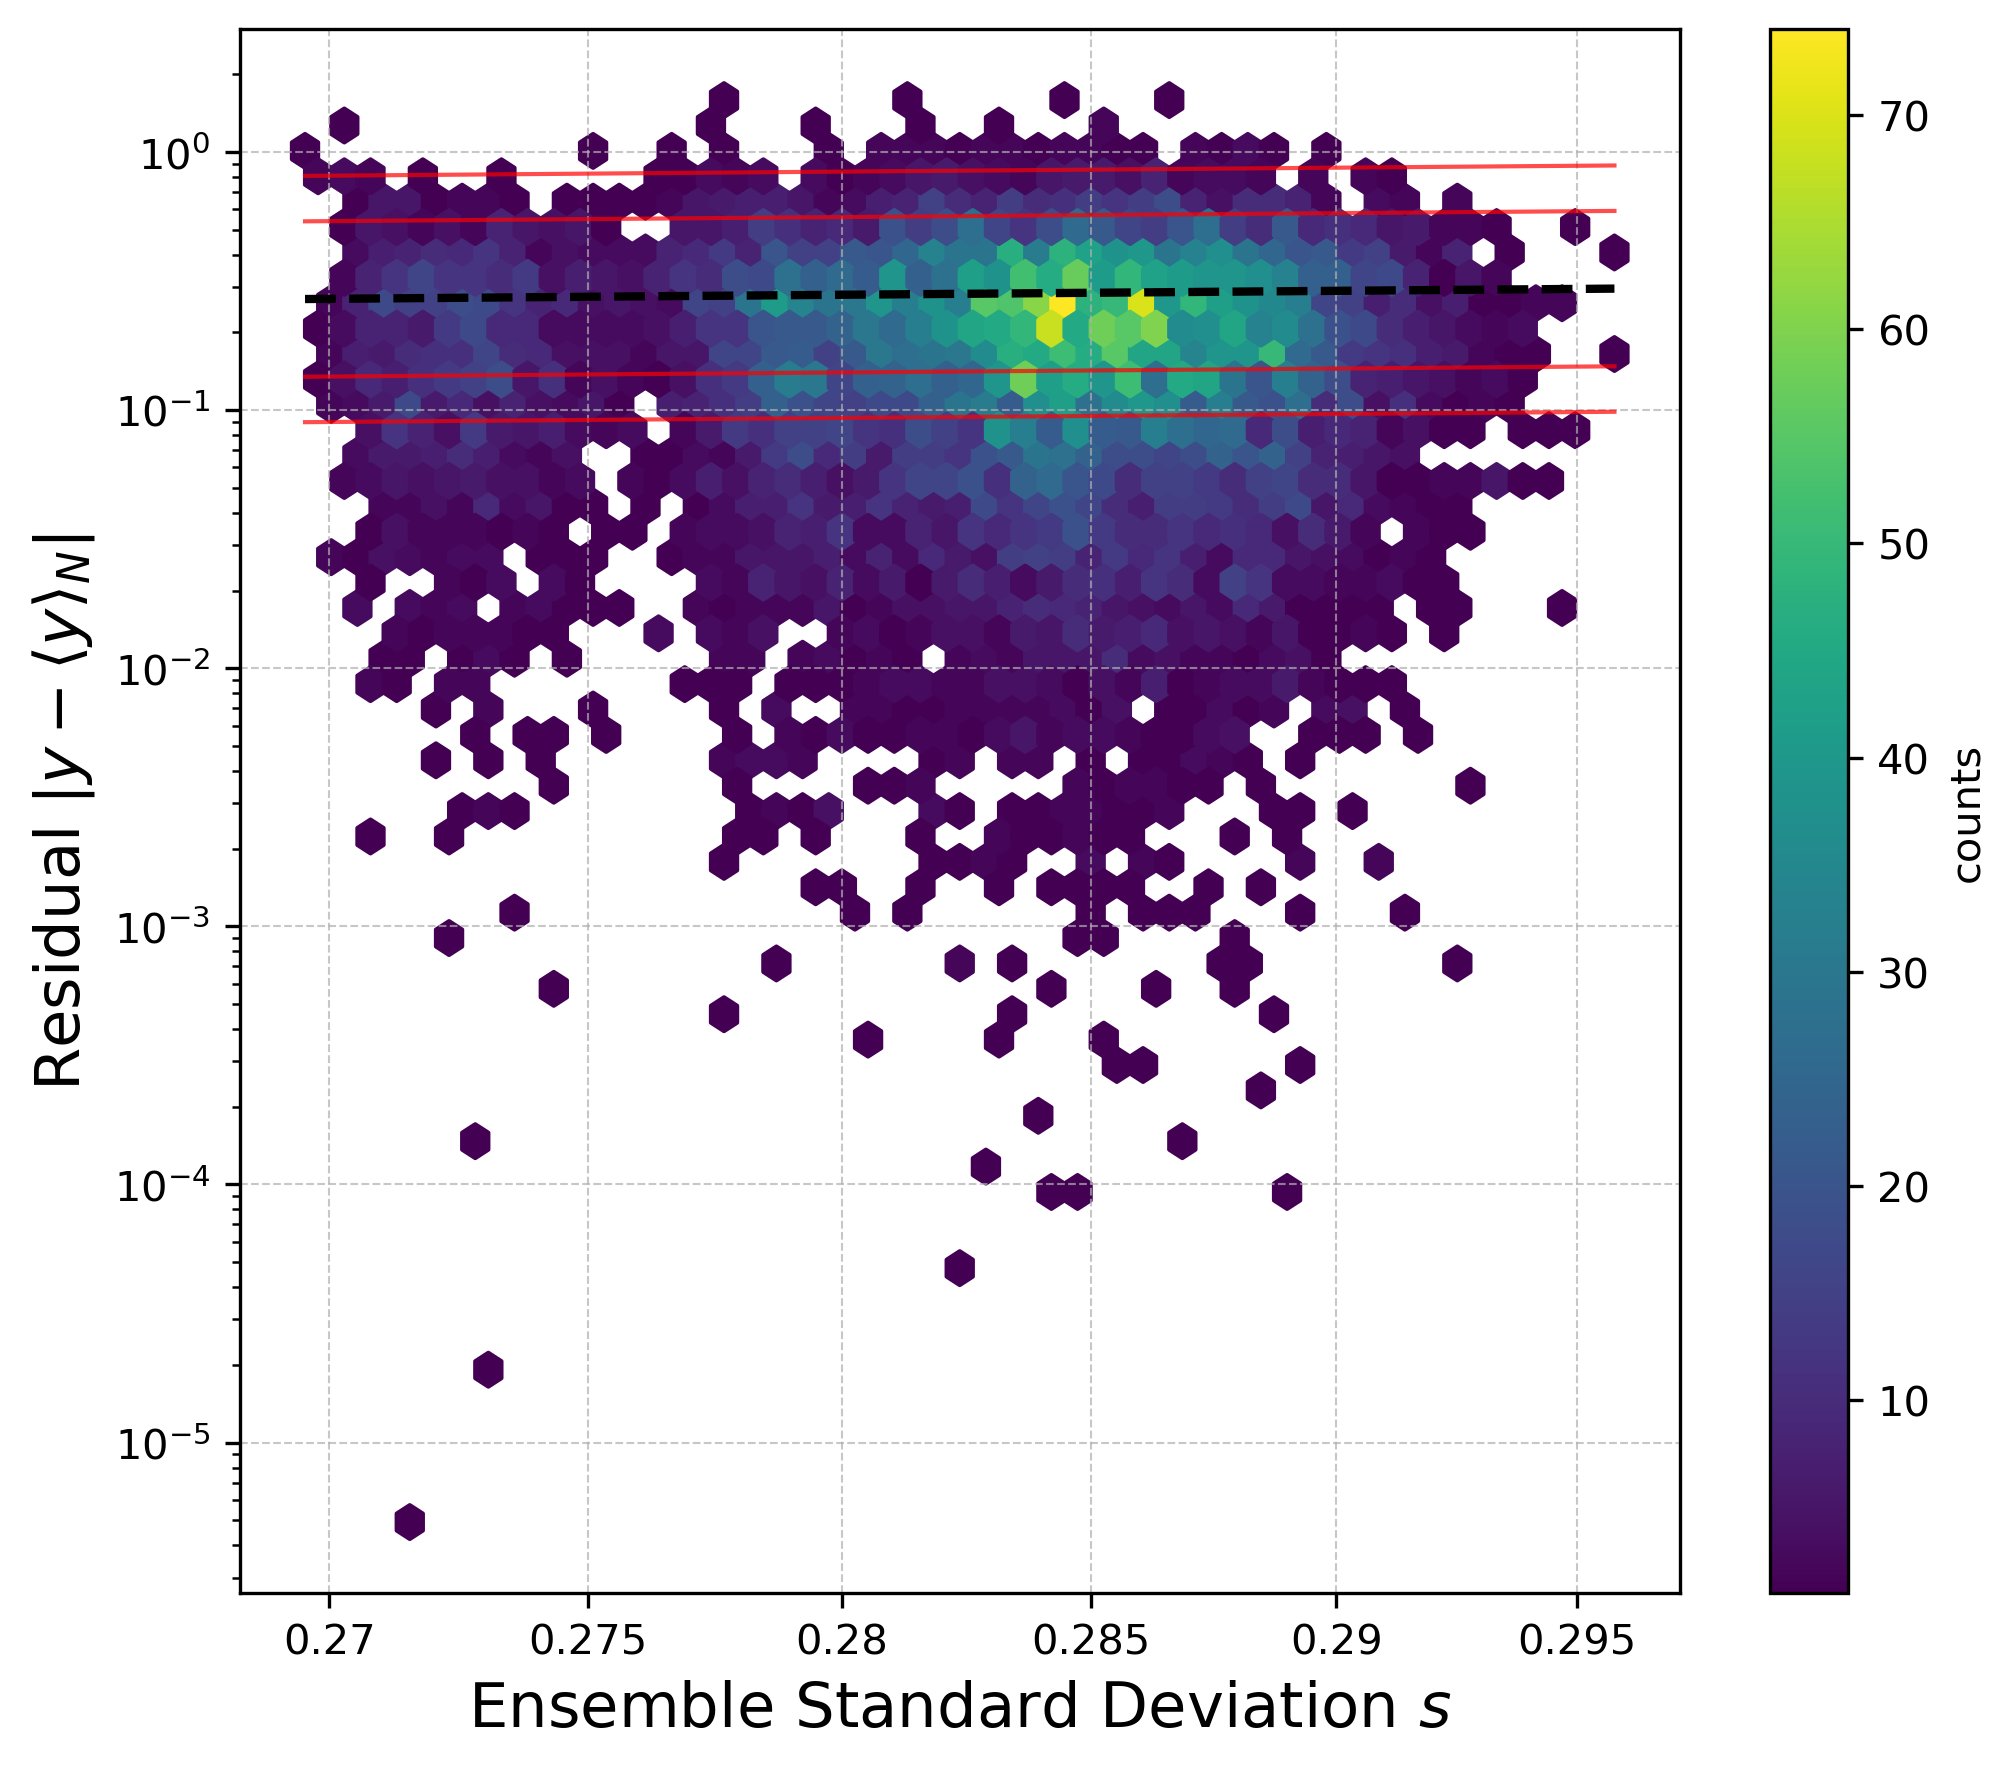

In [45]:
plt.figure(figsize=(7, 6), dpi=300)

x = np.sqrt(var_emp)  # predicted uncertainty 
y = np.abs(y_obs - y_emp)  # empirical error (not squared)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# reference line y = x 
xmin, xmax = x.min(), x.max()
xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
plt.plot(xline, xline, 'k--', lw=2, label=r'$y = s$')

# sigma lines: y = n·σ
sigma_multipliers = [1/3, 1/2, 2, 3]
for n in sigma_multipliers:
    plt.plot(xline, n * xline,
             linestyle='-',
             color='red',
             lw=1,
             alpha=0.7)

# hexbin
plt.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
           mincnt=1, cmap='viridis')
plt.colorbar(label='counts')
plt.xlabel(r'Ensemble Standard Deviation $s$', fontsize = 15)
plt.ylabel(r'Residual $|y - \langle y \rangle_N|$', fontsize = 15)
plt.xscale('log')
plt.yscale('log')
plt.xticks([0.27, 0.275, 0.28, 0.285, 0.29, 0.295], labels = ['0.27', '0.275', '0.28', '0.285', '0.29', '0.295']
)
#plt.legend()
plt.tight_layout()
plt.savefig('Calibration.pdf')
plt.show()

## Within-Alpha

In [17]:
# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    # Centering of the uncertainty --> If alpha=95 then 5% of the observations will fall outside this interval and they will be split into le lowest and highest quantiles
    # the lowest quantile will be 5/2 = 2.5 and the highest quantile 100 - 2.5 = 97.5
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    # Checks whether the true value lies inside the given interval
    inside = (y_true >= lower) & (y_true <= upper)
    # Computes the mean over the inner values
    return float(np.mean(inside)), lower, upper

In [18]:
y_test = np.array(data_test['logD'])

In [19]:
# Montecarlo predictive posterior values
files_ppc = [f"/home/paolo/Thesis/Na/pp_desc_dim_norm_lnD_dd4/pp_model_{i}.nc" for i in range(10)]
ppcs = [az.from_netcdf(f) for f in files_ppc]

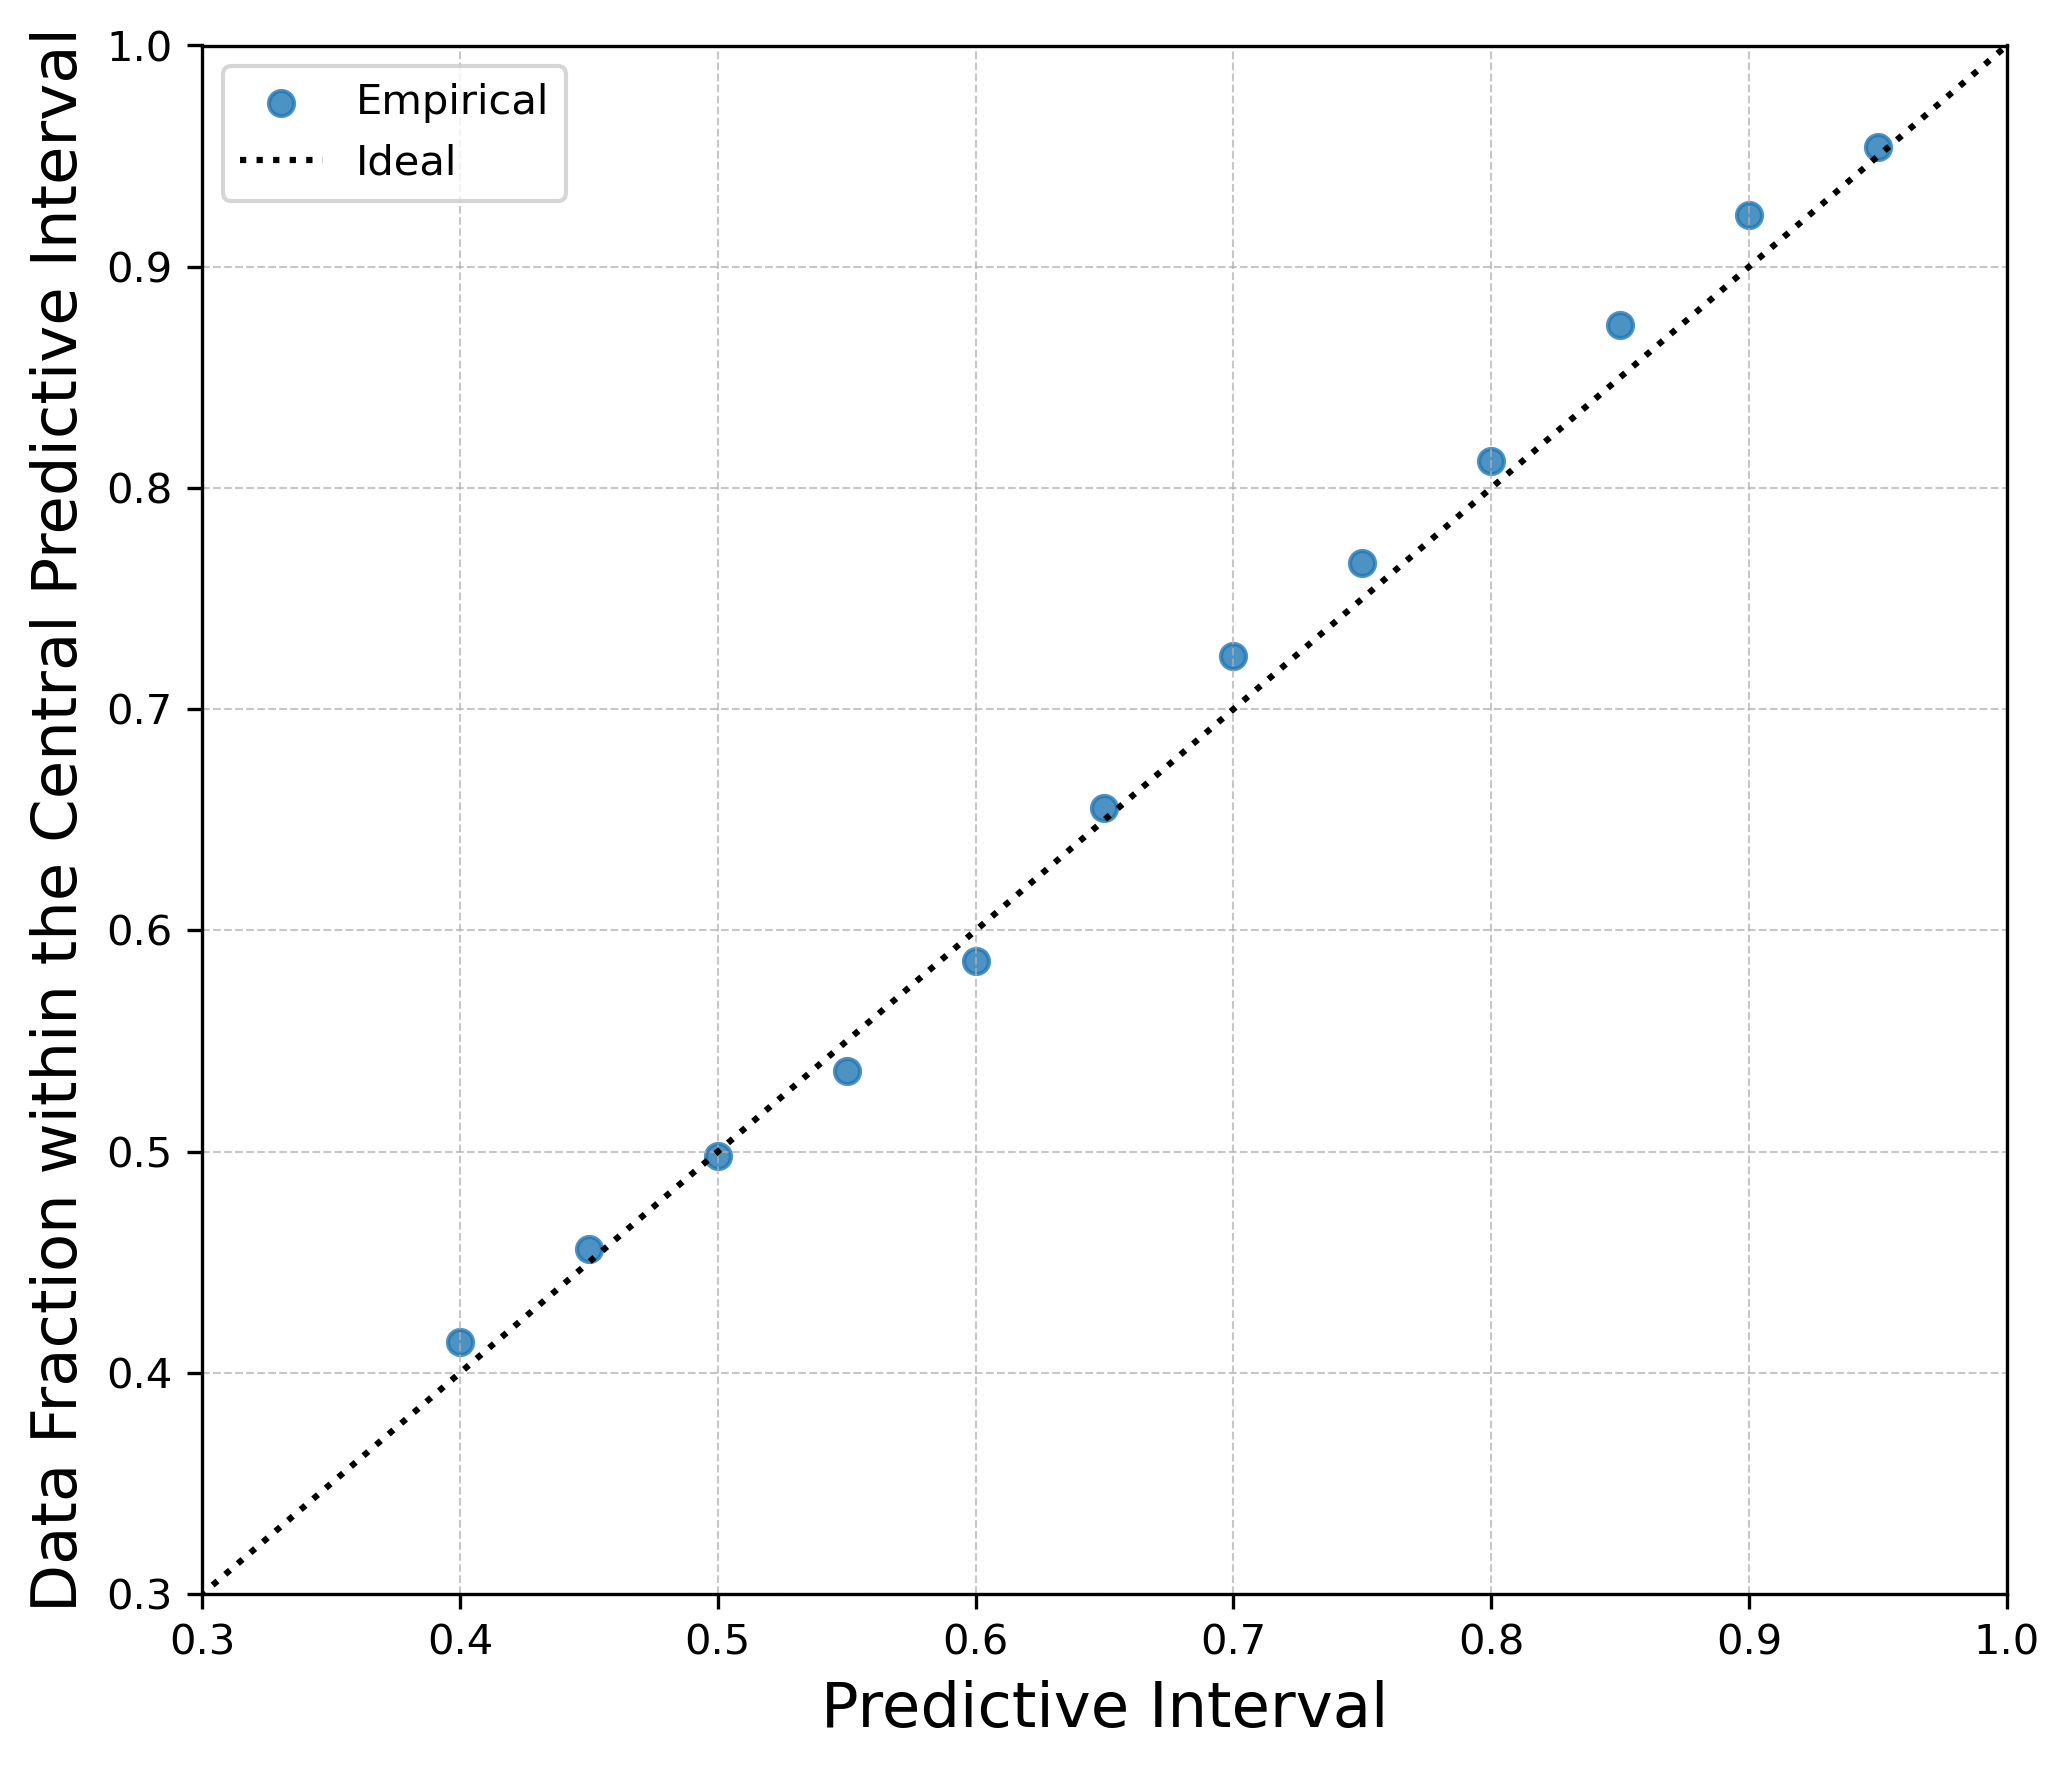

In [22]:
plt.figure(figsize=(7, 6), dpi=300)

walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[1].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.scatter(alphas,walphas, alpha=0.8, label='Empirical')
plt.ylabel('Data Fraction within the Central Predictive Interval', fontsize = 15)
plt.xlabel('Predictive Interval', fontsize = 15)
plt.plot([0,1],[0,1],linestyle=':',color='black',label='Ideal')

# Limits
plt.xlim(0.3, 1)
plt.ylim(0.3, 1)

plt.legend()
plt.tight_layout()
plt.savefig('within.pdf')
plt.show()

# E vs Rest

In [23]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize_units(data_train)
T = 300
EvsRest = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data_train['Ea']))], 
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data_train['PF'],
    "VPA": data['VPA'],
    "NBI": data_train['NBI'],
    "SBI": data_train['SBI'],
    "RBI": data_train['RBI'],
    "WE": data_train['weighted_electronegativity'],
    "B": data_train['B'],
    "N": data_train['N'],
    "S": data_train['S'],
    "O": data_train['O'],
    "F": data_train['F'],
    "Na": data_train['Na'],
    "Al": data_train['Al'],
    "Si": data_train['Si'],
    "P": data_train['P'],
    "Cl": data_train['Cl'],
    "Ge": data_train['Ge'],
    "Br": data_train['Br'],
    "I": data_train['I'],

    # Volume
    "cub_root_V" : data['cub_root_V'],
    
    # Na–Na distances
    "Na-Na": data['Na-Na'],
    "Na-Na-max": data['Na-Na-max'],
    "Na-Na-avg": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min": data['bottleneck_min'],
    "bottleneck_avg": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data_train['poly_dist_max'],
    "poly_dist_std": data_train['poly_dist_std'],
    "poly_dist_avg": data_train['poly_dist_avg'],
    "poly_dist_avg_fixed": data_train['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max": data['face-area-max'],
    "face-area-avg": data['face-area-avg'],
    "face-area-min": data['face-area-min'],
    "face-area-count": data_train['face-area-count'],

    # Pockets
    "pockets-per-ion": data_train['pockets-per-ion'],
    "pockets-per-volume": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data_train['paths-per-ion'],
    "paths-per-volume": data['paths-per-volume'],

    # Target
    "E_T": data['E']/(kb*300)
})    

## SISSO Initialization

In [113]:
n_feat = 39
EvsRest.to_csv(f"/home/paolo/Thesis/Na/data/final/Na_Ea{n_feat}_temp300_unitless_v2.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/final/Na_Ea{n_feat}_temp300_unitless_v2.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [96]:
# Try the fit with the exact functional form
rung = 1
desc_dim = 4
Diff_json = {
    'data_file': data_file,
     'property_key': 'E_T',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/final/Ea{n_feat}_{rung}_{desc_dim}_unitless_v2.json", "w"), indent=4)

## Formula Extraction

In [24]:
def extract_dd4_Ea(ms = 10, rung=1, feat = 39):
    '''Extract the Ea formulas and the values of the parameters from the SISSO output for desc_dim=4 and Rung=1'''
    dd = 4
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    a3_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/final/models_Ea{feat}_{rung}_{dd}_unitless/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            a3_i = parts[6].rstrip(',')
            c0_i = parts[7].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            a3_list.append(a3_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, a3_list, c0_list)

In [25]:
raw_formulas2, a0_list2, a1_list2, a2_list2, a3_list2, c0_list2 =extract_dd4_Ea()

In [26]:
raw_formulas2

['c0 + a0 * (face-area-avg * AAV) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (face-area-avg * VPA) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (face-area-avg * bottleneck_avg) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (face-area-avg * cub_root_V) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (face-area-avg * AAV) + a1 * (Ge * S) + a2 * (poly_dist_avg_fixed - SBI) + a3 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (face-area-count * poly_dist_avg) + a1 * (Ge * S) + a2 * (SBI / RBI) + a3 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (cub_root_V * AAV) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (face-area-avg * cub_root_V) + a1 * (Ge * S) + a2 * (poly_dist_avg_fixed - S

In [27]:
def sanitize(expr):
    '''
    Fix Descriptor names
    '''
    return (
        expr
        .replace('Na-Na-avg', 'Na_Na_avg')
        .replace('Na-Na-max', 'Na_Na_max')
        .replace('Na-Na', 'Na_Na')
        .replace('face-area-avg', 'face_area_avg')
        .replace('face-area-max', 'face_area_max')
        .replace('face-area-min', 'face_area_min')
        .replace('face-area-count', 'face_area_count')
        .replace('cub_root_V', 'cub_root_V')
        .replace('pockets-per-ion', 'pockets_per_ion')
        .replace('pockets-per-volume', 'pockets_per_volume')
        .replace('paths-per-ion', 'paths_per_ion')
        .replace('paths-per-volume', 'paths_per_volume')
    )

In [28]:
formulas2 = [sanitize(f) for f in raw_formulas2]
formulas2

['c0 + a0 * (face_area_avg * AAV) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (face_area_avg * VPA) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (face_area_avg * bottleneck_avg) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (face_area_avg * cub_root_V) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (face_area_avg * AAV) + a1 * (Ge * S) + a2 * (poly_dist_avg_fixed - SBI) + a3 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (face_area_count * poly_dist_avg) + a1 * (Ge * S) + a2 * (SBI / RBI) + a3 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (cub_root_V * AAV) + a1 * (Ge * S) + a2 * (poly_dist_avg - SBI) + a3 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (face_area_avg * cub_root_V) + a1 * (Ge * S) + a2 * (poly_dist_avg_fixed - S

In [29]:
a0_2 = np.array(a0_list2, dtype=float)
a1_2 = np.array(a1_list2, dtype=float)
a2_2 = np.array(a2_list2, dtype=float)
a3_2 = np.array(a3_list2, dtype=float)
c0_2 = np.array(c0_list2, dtype=float)

In [30]:
# Coefficients are separated from function blocks to be later added as distributions
a0_sym, a1_sym, a2_sym, a3_sym, c0_sym = sp.symbols('a0 a1 a2 a3 c0')
symbols = sp.symbols(
    '''
    Ea B N O F Na Al Si P S Cl Ge Br I
    density AAV PF SBI RBI VPA NBI weighted_electronegativity cub_root_V
    bottleneck_min bottleneck_avg
    poly_dist_avg poly_dist_max poly_dist_std poly_dist_avg_fixed
    Na_Na Na_Na_max Na_Na_avg
    face_area_max face_area_avg face_area_min face_area_count
    pockets_per_ion pockets_per_volume
    paths_per_ion paths_per_volume
    '''
)

locals_dict = {s.name: s for s in symbols}
# convert strings to sympy expressions
sympy_exprs = [sp.sympify(f, locals=locals_dict) for f in formulas2]

pruned = []
# Prunes the coefficients that will be added later as distributions
for f in sympy_exprs:
    row = [
        sp.simplify(f.coeff(a0_sym)),
        sp.simplify(f.coeff(a1_sym)),
        sp.simplify(f.coeff(a2_sym)),
        sp.simplify(f.coeff(a3_sym)),
    ]
    pruned.append(row)

pruned

[[AAV*face_area_avg,
  Ge*S,
  -SBI + poly_dist_avg,
  face_area_count + pockets_per_volume],
 [VPA*face_area_avg,
  Ge*S,
  -SBI + poly_dist_avg,
  face_area_count + pockets_per_volume],
 [bottleneck_avg*face_area_avg,
  Ge*S,
  -SBI + poly_dist_avg,
  face_area_count + pockets_per_volume],
 [cub_root_V*face_area_avg,
  Ge*S,
  -SBI + poly_dist_avg,
  face_area_count + pockets_per_volume],
 [AAV*face_area_avg,
  Ge*S,
  -SBI + poly_dist_avg_fixed,
  face_area_count + pockets_per_volume],
 [face_area_count*poly_dist_avg,
  Ge*S,
  SBI/RBI,
  face_area_count + pockets_per_volume],
 [AAV*cub_root_V,
  Ge*S,
  -SBI + poly_dist_avg,
  face_area_count + pockets_per_volume],
 [cub_root_V*face_area_avg,
  Ge*S,
  -SBI + poly_dist_avg_fixed,
  face_area_count + pockets_per_volume],
 [AAV*face_area_avg,
  Ge*S,
  -SBI + poly_dist_avg,
  face_area_count + paths_per_volume],
 [VPA*face_area_avg,
  Ge*S,
  -SBI + poly_dist_avg_fixed,
  face_area_count + pockets_per_volume]]

In [31]:
vars_ = [
    locals_dict[k] for k in [
        'B', 'N', 'S', 'O', 'F', 'Na', 'Al', 'Si', 'P', 'Cl', 'Ge', 'Br', 'I', 'density', 'AAV', 'PF', 'NBI', 'SBI', 'RBI', 'VPA', 'weighted_electronegativity', 'cub_root_V', 
        'Na_Na', 'Na_Na_max', 'Na_Na_avg', 'bottleneck_min', 'bottleneck_avg', 'poly_dist_max', 'poly_dist_std', 'poly_dist_avg', 'poly_dist_avg_fixed',
        'face_area_max', 'face_area_avg', 'face_area_min', 'face_area_count', 
        'pockets_per_ion', 'pockets_per_volume', 'paths_per_ion', 'paths_per_volume',
    ]
]
# Feature functions
Phi = [
    sp.lambdify(vars_, row, modules="numpy")
    for row in pruned
]

In [32]:
data = initialize_units(data_train)
X = np.array([
    phi(
        data_train['B'],
        data_train['N'],
        data_train['S'],
        data_train['O'],
        data_train['F'],
        data_train['Na'],
        data_train['Al'],
        data_train['Si'],
        data_train['P'],
        data_train['Cl'],
        data_train['Ge'],
        data_train['Br'],
        data_train['I'],
        
        data['density'],
        data['AAV'],
        data_train['PF'],
        data_train['NBI'],
        data_train['SBI'],
        data_train['RBI'],
        data['VPA'],
        data_train['weighted_electronegativity'],
        
        
        # Volume
        data['cub_root_V'],
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data_train['poly_dist_max'],
        data_train['poly_dist_std'],
        data_train['poly_dist_avg'],
        data_train['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data_train['face-area-count'],
        
        # Pockets
        data_train['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data_train['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [33]:
data2 = initialize_units(data_test)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
X_test = np.array([
    phi(
        data_test['B'],
        data_test['N'],
        data_test['S'],
        data_test['O'],
        data_test['F'],
        data_test['Na'],
        data_test['Al'],
        data_test['Si'],
        data_test['P'],
        data_test['Cl'],
        data_test['Ge'],
        data_test['Br'],
        data_test['I'],
        
        data2['density'],
        data2['AAV'],
        data_test['PF'],
        data_test['NBI'],
        data_test['SBI'],
        data_test['RBI'],
        data2['VPA'],
        data_test['weighted_electronegativity'],
        
        
        # Volume
        data2['cub_root_V'],
        
        # Na–Na distances
        data2['Na-Na'],
        data2['Na-Na-max'],
        data2['Na-Na-avg'],
        
        # Bottleneck descriptors
        data2['bottleneck_min'],
        data2['bottleneck_avg'],
        
        # Polyhedral distortion
        data_test['poly_dist_max'],
        data_test['poly_dist_std'],
        data_test['poly_dist_avg'],
        data_test['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data2['face-area-max'],
        data2['face-area-avg'],
        data2['face-area-min'],
        data_test['face-area-count'],
        
        # Pockets
        data_test['pockets-per-ion'],
        data2['pockets-per-volume'],
        
        # Paths
        data_test['paths-per-ion'],
        data2['paths-per-volume'],
    )
    for phi in Phi
])

In [18]:
X

array([[[ 7.46967490e-01,  3.51034893e-02,  6.66611947e-01, ...,
          2.94013940e+00, -5.42124006e-02,  1.34268971e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 6.41767320e-02,  1.76213911e-01, -9.36388494e-02, ...,
         -1.90894401e-02,  6.67700712e-02,  6.98888487e-02],
        [ 2.66378834e+01,  2.86485402e+01,  3.97144943e+01, ...,
          1.33561565e+01,  3.29303939e+01,  1.49952680e+01]],

       [[ 1.02837726e+00,  6.93262540e-02,  6.61144641e-01, ...,
          2.73577922e+00, -1.15393985e-01,  9.41705622e-01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 6.41767320e-02,  1.76213911e-01, -9.36388494e-02, ...,
         -1.90894401e-02,  6.67700712e-02,  6.98888487e-02],
        [ 2.66378834e+01,  2.86485402e+01,  3.97144943e+01, ...,
          1.33561565e+01,  3.29303939e+01,  1.49952

In [19]:
np.max(c0_2), np.max(a0_2), np.max(a1_2), np.max(a2_2), np.max(a3_2)

(np.float64(2.545322049742511),
 np.float64(0.07871849643795312),
 np.float64(8.809713897016858),
 np.float64(2.80610389708902),
 np.float64(-0.07044804843404945))

In [19]:
traces2 = []
ppcs2 = []
models_stored = 10
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = X[i, :, :]
        f_test = X_test[i, :, :]

        # Priors
        c0_coeff = pm.Normal("c0", mu=c0_2[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0_2[i], sigma=10)
        a1_coeff = pm.Normal("a1", mu=a1_2[i], sigma=10)
        a2_coeff = pm.Normal("a2", mu=a2_2[i], sigma=10)
        a3_coeff = pm.Normal("a3", mu=a3_2[i], sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :] + a3_coeff * f[3, :]

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data['E'])

        # Sample from posterior
        trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)

        # Posterior predictive for the TEST set:
        # Create a new RV for test predictions using the same parameters.
        mu_test = pm.Deterministic("mu_test", c0_coeff + a0_coeff * f_test[0, :] + a1_coeff * f_test[1, :] + a2_coeff * f_test[2, :] + a3_coeff * f_test[3, :])
        y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)
        
        ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y_test"],
        random_seed=123
    )
        
        #trace = pm.sample()
        traces2.append(trace)
        ppcs2.append(ppc)
        
        idata = trace.posterior
        az.to_netcdf(idata, f"trace2_model_{i}.nc")
        az.to_netcdf(ppc, f"pp2_model_{i}.nc")

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

In [20]:
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces2[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[-1041.29671407 -1040.74103891 -1040.3431786  -1040.11943113]
[-1043.30978262 -1042.20737372 -1041.51417303 -1041.83358456]
[-1041.79458353 -1041.36810833 -1042.18968898 -1041.38667303]
[-1042.49159311 -1042.5854341  -1042.49143318 -1042.05309521]
[-1043.59342351 -1043.03657812 -1043.07446911 -1042.81059603]
[-1043.16436334 -1043.69247756 -1043.91814432 -1042.61897983]
[-1043.8943794  -1043.29215778 -1042.48054869 -1043.56467754]
[-1042.89550873 -1044.04862267 -1042.97119902 -1043.05609739]
[-1044.13632505 -1042.45820235 -1042.58375786 -1043.50466148]
[-1043.70182276 -1043.59942714 -1043.35212403 -1044.03643626]


In [21]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml

(np.float64(-1040.6250906796695), np.int64(0))

In [22]:
# Computes the marginal likelihood ratios between the given model and the benchmark
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(1.0),
 np.float64(0.20369371602282665),
 np.float64(0.3465691937971206),
 np.float64(0.16858786355480007),
 np.float64(0.08178380699197856),
 np.float64(0.06565112239580297),
 np.float64(0.06836801555099035),
 np.float64(0.07296566630204096),
 np.float64(0.07842237438647232),
 np.float64(0.04748402840996152)]

In [23]:
np.argsort(ml_diff)

array([9, 5, 6, 7, 8, 4, 3, 1, 2, 0])

## Tempering

In [20]:
beta = np.array([1/8, 1/4, 1/2])
beta

array([0.125, 0.25 , 0.5  ])

In [21]:
traces_temp = []
models_stored = 10
for i in range(models_stored):
    traces_i = []
    for j in beta:
        with pm.Model() as model:
            # Select the i-th column
            f = X[i, :, :]
            f_test = X_test[i, :, :]
    
            # Priors weakly informative
            c0_coeff = pm.Normal("c0", mu=c0_2[i], sigma=10)
            a0_coeff = pm.Normal("a0", mu=a0_2[i], sigma=10)
            a1_coeff = pm.Normal("a1", mu=a1_2[i], sigma=10)
            a2_coeff = pm.Normal("a2", mu=a2_2[i], sigma=10)
            a3_coeff = pm.Normal("a3", mu=a3_2[i], sigma=10)
            sigma = pm.HalfNormal("sigma", sigma=10) #try lower?
    
            # Linear parametrization
            mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :] + a3_coeff * f[3, :]
    
    
            # Standard log-likelihood
            dist = pm.Normal.dist(mu=mu, sigma=sigma)
            logp = pm.logp(dist, data['E'])

            # Tempered likelihood --> log (y| theta) = sum_n log(y_n|theta)
            pm.Potential("tempered_likelihood", j * logp.sum())
    
            # Sample from posterior
            # Sequential montecarlo
            trace = pm.smc.sample_smc(draws=8000, chains=4, threshold=0.5, random_seed = 123)
            #trace = pm.sample()
            traces_i.append(trace)
    traces_temp.append(traces_i)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

array([[<Axes: title={'center': 'c0'}>, <Axes: title={'center': 'c0'}>],
       [<Axes: title={'center': 'a0'}>, <Axes: title={'center': 'a0'}>],
       [<Axes: title={'center': 'a1'}>, <Axes: title={'center': 'a1'}>],
       [<Axes: title={'center': 'a2'}>, <Axes: title={'center': 'a2'}>],
       [<Axes: title={'center': 'a3'}>, <Axes: title={'center': 'a3'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

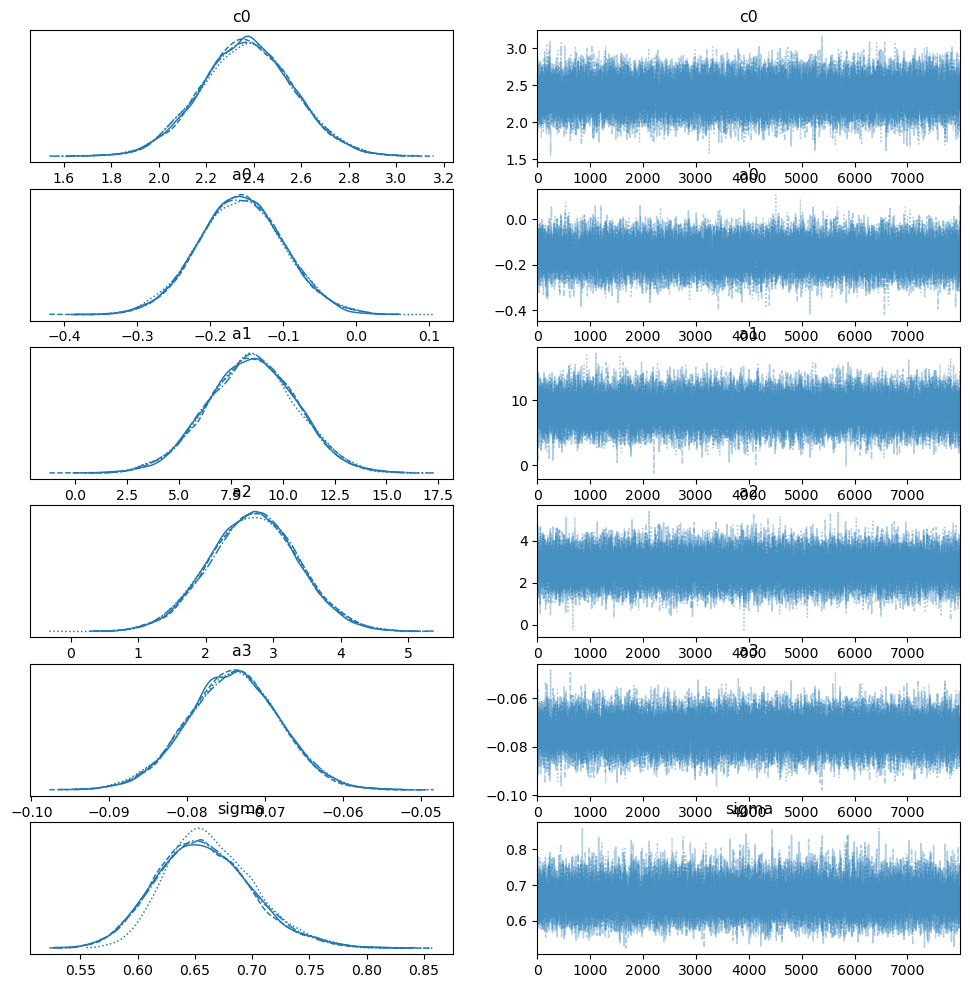

In [22]:
az.plot_trace(traces_i[0])

In [23]:
marginal_likelihoods_temp = []
log_marginal_likelihoods_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        log_ml_raw = traces_temp[i][j].sample_stats["log_marginal_likelihood"].values
    
        # Flatten possible nested lists and cast to floats
        flattened = []
        for row in log_ml_raw.ravel():
            # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
            if isinstance(row, (list, tuple, np.ndarray)):
                flattened.extend(row)
            # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
            else:
                flattened.append(row)
        # This ensures that everything inside flattened is a single scalar number, not a list or array.
        log_ml_temp = np.array(flattened, dtype=float)
        # Checks that the entry is effectively a number
        log_ml_temp = log_ml_temp[~np.isnan(log_ml_temp)]
        #print(log_ml_temp)
        # Computes the mean
        mean_log_ml_temp = np.mean(log_ml_temp)
        log_marginal_likelihoods_temp.append(mean_log_ml_temp)

In [24]:
log_marginal_likelihoods_temp = np.array(log_marginal_likelihoods_temp).reshape(models_stored, len(beta))

In [25]:
# For each value of beta (comlumn) finds the representative with the highest marginal likelihood
for j in range(len(beta)):
    print(np.argmax(log_marginal_likelihoods_temp[:,j]))

2
1
2


In [26]:
ml_diff_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        # log_marginal_likelihoods_temp[np.argmax(marginal_likelihoods_temp[:,j]), j] --> log_marg_likelihood of the benchmark for that value of beta
        # e.g. if j=1 --> np.argmax(marginal_likelihoods_temp[:,j]) = (1,1) --> log_marginal_likelihoods_temp[1, 1]
        ml_diff_temp.append(np.exp(-(log_marginal_likelihoods_temp[np.argmax(log_marginal_likelihoods_temp[:,j]), j] - log_marginal_likelihoods_temp[i,j])))

In [27]:
ml_diff_temp = np.array(ml_diff_temp).reshape(models_stored, len(beta))
ml_diff_temp.T # Each row corresponds to the ml difference computed with the same value of beta for the different models

array([[0.17915281, 0.24893245, 1.        , 0.18798111, 0.0679907 ,
        0.01550882, 0.06675897, 0.32183651, 0.17805911, 0.18133039],
       [0.31736725, 1.        , 0.90576928, 0.21698983, 0.39734657,
        0.0628121 , 0.53045207, 0.06559287, 0.05089911, 0.16397067],
       [0.48331896, 0.76397534, 1.        , 0.22649611, 0.13839228,
        0.03488706, 0.1288253 , 0.0680611 , 0.16198351, 0.20250915]])

In [28]:
# Indices corresponding to the entries sorted in ascending order for beta = 1/8, 1/4, 1/2
np.argsort(ml_diff_temp.T)

array([[5, 6, 4, 8, 0, 9, 3, 1, 7, 2],
       [8, 5, 7, 9, 3, 0, 4, 6, 2, 1],
       [5, 7, 6, 4, 8, 9, 3, 0, 1, 2]])

In [23]:
ordering2 = np.array([[5, 6, 4, 8, 0, 9, 3, 1, 7, 2],
       [8, 5, 7, 9, 3, 0, 4, 6, 2, 1],
       [5, 7, 6, 4, 8, 9, 3, 0, 1, 2],
       [9, 5, 6, 7, 8, 4, 3, 1, 2, 0]])[:, ::-1]

<Figure size 1800x1800 with 0 Axes>

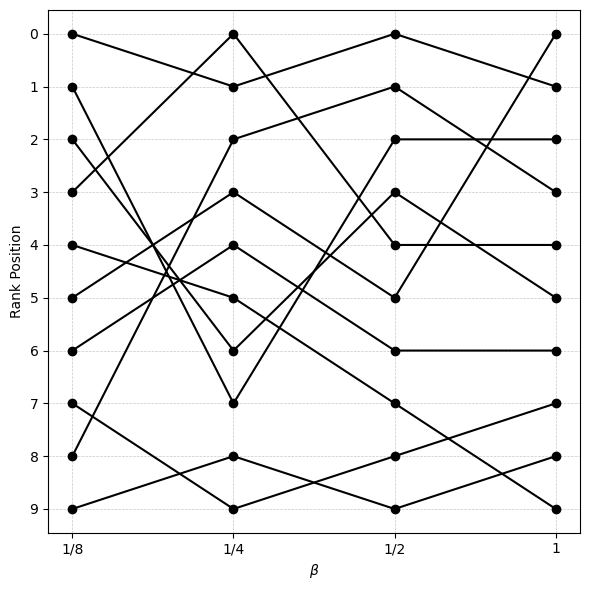

In [23]:
plt.figure(figsize=(6, 6), dpi=300)
steps = range(ordering2.shape[0])
values = range(10)

plt.figure(figsize=(6,6))

for v in values:
    positions = [np.where(ordering2[i] == v)[0][0] for i in steps]
    plt.plot(steps, positions, marker='o', label=str(v), color = 'black')

plt.gca().invert_yaxis()
plt.xticks(steps, [ r'1/8', r'1/4', r'1/2', r'1'])
plt.yticks([0,1,2,3,4,5,6,7,8,9])
plt.ylabel("Rank Position")
plt.xlabel(r"$\beta$")
#plt.title("Rank changes across vectors")

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
#plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.savefig('Tempering_Ea_v1.pdf')
plt.show()

<Figure size 1800x1800 with 0 Axes>

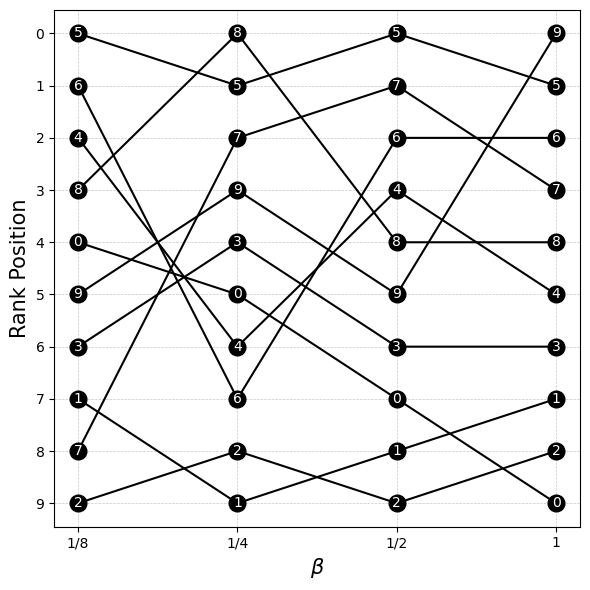

In [202]:
plt.figure(figsize=(6, 6), dpi=300)

steps = range(ordering2.shape[0])
values = range(10)

plt.figure(figsize=(6,6))

for v in values:
    positions = [np.where(ordering2[i] == v)[0][0] for i in steps]
    plt.plot(steps, positions, marker='o', markersize = 12, color='black')

    # Add labels inside markers
    for x, y in zip(steps, positions):
        plt.text(x, y, str(v),
                 ha='center', va='center',
                 fontsize=10, color='white')

plt.gca().invert_yaxis()
plt.xticks(steps, [r'1/8', r'1/4', r'1/2', r'1'])
plt.yticks([0,1,2,3,4,5,6,7,8,9])
plt.ylabel("Rank Position", fontsize=15)
plt.xlabel(r"$\beta$", fontsize=15)

ax = plt.gca()
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

#plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()

plt.savefig('tempering_Ea_v2.pdf')
plt.show()

## Best Model

In [124]:
# Montecarlo posterior values
files = [f"/home/paolo/Thesis/Na/mc_desc_dim_norm_Ea_dd4/trace2_model_{i}.nc" for i in range(10)]
traces_list2 = [az.from_netcdf(f) for f in files]
traces2 = traces_list2

In [125]:
c0_post = []
a0_post = []
a1_post = []
a2_post = []
a3_post = []
for m in range(models_stored):
    c0_post.append(np.mean(traces2[m].posterior['c0'].values.flatten()))
    a0_post.append(np.mean(traces2[m].posterior['a0'].values.flatten()))
    a1_post.append(np.mean(traces2[m].posterior['a1'].values.flatten()))
    a2_post.append(np.mean(traces2[m].posterior['a2'].values.flatten()))
    a3_post.append(np.mean(traces2[m].posterior['a3'].values.flatten()))

In [126]:
c0_post[4], a0_post[4], a1_post[4], a2_post[4], a3_post[4] 

(np.float64(2.3662236216410775),
 np.float64(-0.1418263108698807),
 np.float64(8.666813077936727),
 np.float64(2.7129642186423477),
 np.float64(-0.07358244242560522))

In [127]:
c0_post_std[4], a0_post_std[4], a1_post_std[4], a2_post_std[4], a3_post_std[4] 

(np.float64(0.06657227810480036),
 np.float64(0.017955806404865403),
 np.float64(0.7433645289040546),
 np.float64(0.22349093351158666),
 np.float64(0.0020386241299373813))

In [128]:
c0_post_std = []
a0_post_std = []
a1_post_std = []
a2_post_std = []
a3_post_std = []
for m in range(models_stored):
    c0_post_std.append(np.std(traces2[m].posterior['c0'].values.flatten()))
    a0_post_std.append(np.std(traces2[m].posterior['a0'].values.flatten()))
    a1_post_std.append(np.std(traces2[m].posterior['a1'].values.flatten()))
    a2_post_std.append(np.std(traces2[m].posterior['a2'].values.flatten()))
    a3_post_std.append(np.std(traces2[m].posterior['a3'].values.flatten()))

In [129]:
y_post = []
y_post_test = []
for m in range(models_stored):
    y_post.append(np.array(c0_post[m]) + X[m, 0, :] * np.array(a0_post[m]) + X[m, 1, :] * np.array(a1_post[m]) + X[m, 2, :] * np.array(a2_post[m]) + X[m, 3, :] * np.array(a3_post[m]))
    y_post_test.append(np.array(c0_post[m]) + X_test[m, 0, :] * np.array(a0_post[m]) + X_test[m, 1, :] * np.array(a1_post[m]) + X_test[m, 2, :] * np.array(a2_post[m]) + X_test[m, 3, :] * np.array(a3_post[m]))

In [130]:
y_post = np.array(y_post).T
y_post_test = np.array(y_post_test).T
y_post.shape

(1041, 10)

In [131]:
y_obs = np.tile(data['E'], (10,1)).T
y_obs

array([[ 0.67745724,  0.67745724,  0.67745724, ...,  0.67745724,
         0.67745724,  0.67745724],
       [ 1.96787596,  1.96787596,  1.96787596, ...,  1.96787596,
         1.96787596,  1.96787596],
       [-1.2712852 , -1.2712852 , -1.2712852 , ..., -1.2712852 ,
        -1.2712852 , -1.2712852 ],
       ...,
       [ 1.28468464,  1.28468464,  1.28468464, ...,  1.28468464,
         1.28468464,  1.28468464],
       [ 0.0324672 ,  0.0324672 ,  0.0324672 , ...,  0.0324672 ,
         0.0324672 ,  0.0324672 ],
       [ 2.49603244,  2.49603244,  2.49603244, ...,  2.49603244,
         2.49603244,  2.49603244]], shape=(1041, 10))

In [111]:
# train RMSE
RMSE_train = np.sqrt(np.mean((y_obs - y_post)**2, axis = 0))
RMSE_train

array([0.63716234, 0.63801112, 0.63802116, 0.63809021, 0.63839684,
       0.63848586, 0.63886826, 0.6389132 , 0.63894936, 0.63900601])

In [196]:
# train R^2
from sklearn.metrics import r2_score

r2_score(y_obs.T[0], y_post.T[0]), r2_score(y_obs.T[4], y_post.T[4])

(0.5936337964636144, 0.5920575983179206)

In [193]:
y_obs_test = np.tile(data2['E'], (10,1)).T
y_obs_test

array([[-0.64586049, -0.64586049, -0.64586049, ..., -0.64586049,
        -0.64586049, -0.64586049],
       [ 0.43108133,  0.43108133,  0.43108133, ...,  0.43108133,
         0.43108133,  0.43108133],
       [-1.40381703, -1.40381703, -1.40381703, ..., -1.40381703,
        -1.40381703, -1.40381703],
       ...,
       [-0.45995973, -0.45995973, -0.45995973, ..., -0.45995973,
        -0.45995973, -0.45995973],
       [ 0.42330327,  0.42330327,  0.42330327, ...,  0.42330327,
         0.42330327,  0.42330327],
       [ 0.4496343 ,  0.4496343 ,  0.4496343 , ...,  0.4496343 ,
         0.4496343 ,  0.4496343 ]], shape=(261, 10))

In [194]:
# test RMSE
RMSE_test = np.sqrt(np.mean((y_obs_test - y_post_test)**2, axis = 0))
RMSE_test

array([0.64747839, 0.65145217, 0.64647165, 0.65061798, 0.64468224,
       0.64921691, 0.64624119, 0.64760511, 0.64705036, 0.64891655])

In [197]:
# test R^2
r2_score(y_obs_test.T[0], y_post_test.T[0]), r2_score(y_obs_test.T[1], y_post_test.T[1]), r2_score(y_obs_test.T[2], y_post_test.T[2]), r2_score(y_obs_test.T[4], y_post_test.T[4])

(0.579159323360884, 0.5739778015797332, 0.5804670027808401, 0.5827862887269205)

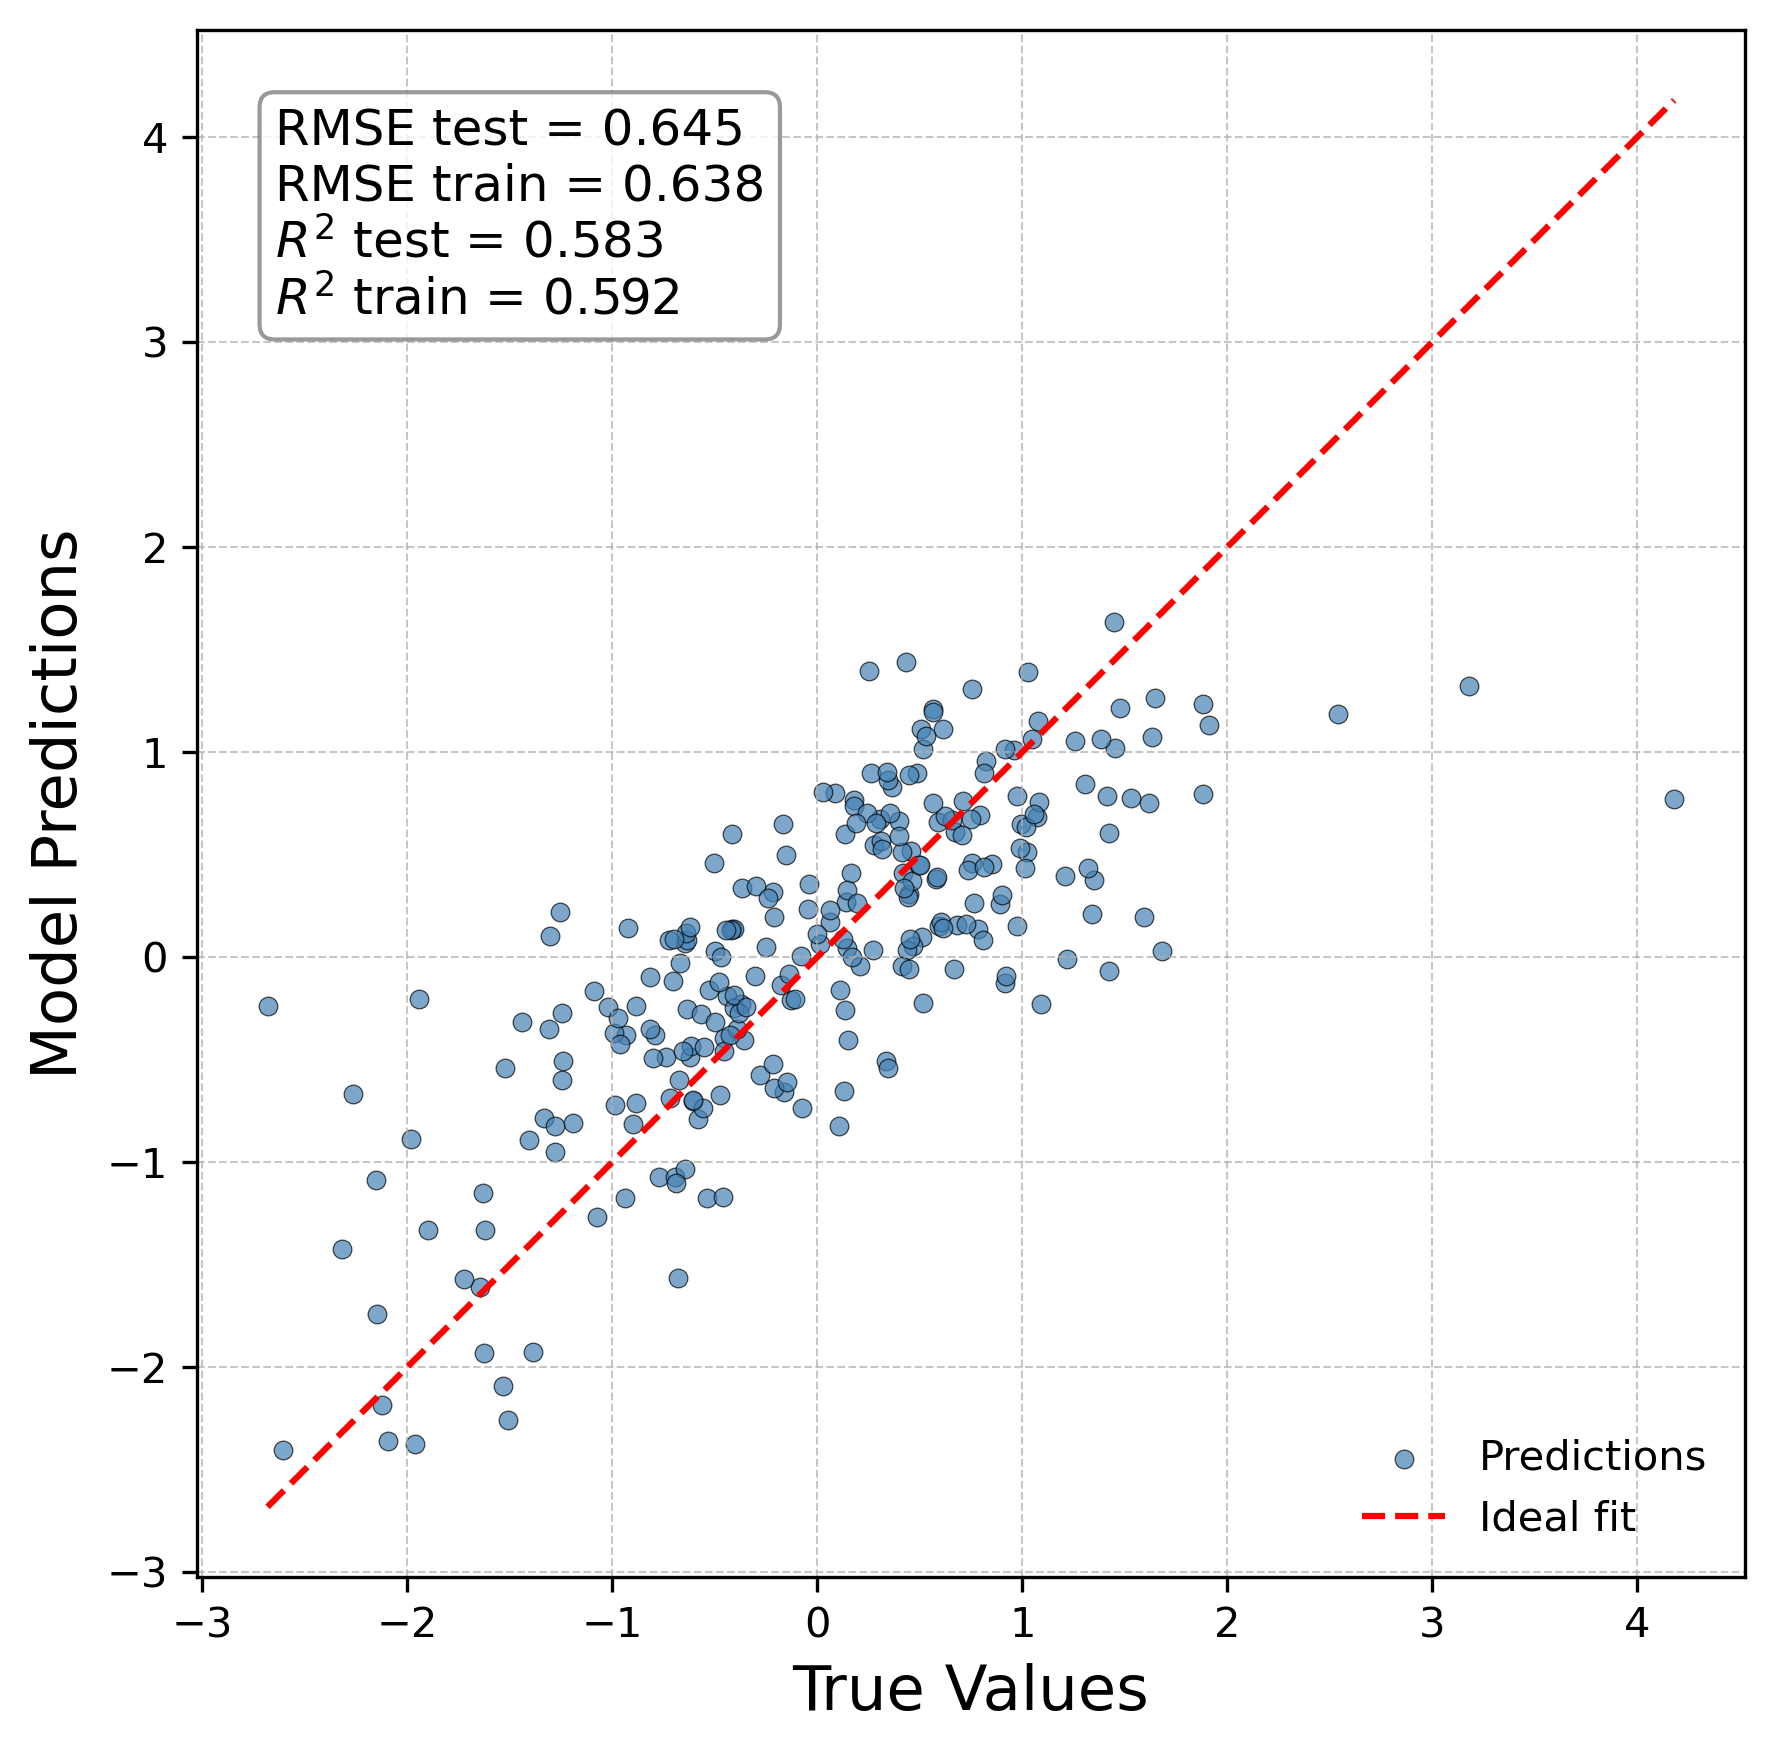

In [199]:
data2 = initialize_units(data_test)
plt.figure(figsize=(6, 6), dpi=300)

# Scatter plot 
plt.scatter(
    data2['E'],
    y_post_test.T[4],
    s=20,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.3,
    color='steelblue',
    label='Predictions'
)

# Identity line (perfect prediction)
min_val = min(data2['E'].min(), y_post_test.T[4].min())
max_val = max(data2['E'].max(), y_post_test.T[4].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Ideal fit'
)


plt.xlabel('True Values', fontsize=15)
plt.ylabel('Model Predictions', fontsize=15)


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


textstr = f'RMSE test = {RMSE_test[4]:.3f}\nRMSE train = {RMSE_train[4]:.3f}\n$R^2$ test = {r2_score(y_obs_test.T[4], y_post_test.T[4]):.3f}\n$R^2$ train = {r2_score(y_obs.T[4], y_post.T[4]):.3f}'

plt.text(
    0.05, 0.95, textstr,             # position in axes coordinates
    transform=plt.gca().transAxes,   # use relative positioning (0–1)
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8,
        edgecolor='gray'
    )
)


plt.gca().set_aspect('equal', adjustable='box')

# Legend
plt.legend(frameon=False, fontsize=10)


plt.tight_layout()

plt.savefig('best_model_Ea.pdf')

plt.show()

## Calibration

In [133]:
np.random.seed(10)
c0_samples_list = []
a0_samples_list = []
a1_samples_list = []
a2_samples_list = []
a3_samples_list = []
sigma_samples_list = []
for m in range(models_stored):
# Draws 200 samples of the parameters from the posterior distribution
    c0_samples_list.append(np.random.choice(traces2[m].posterior['c0'].values.flatten(), size=200, replace=True))
    a0_samples_list.append(np.random.choice(traces2[m].posterior['a0'].values.flatten(), size=200, replace=True))
    a1_samples_list.append(np.random.choice(traces2[m].posterior['a1'].values.flatten(), size=200, replace=True))
    a2_samples_list.append(np.random.choice(traces2[m].posterior['a2'].values.flatten(), size=200, replace=True))
    a3_samples_list.append(np.random.choice(traces2[m].posterior['a3'].values.flatten(), size=200, replace=True))
    sigma_samples_list.append(np.random.choice(traces2[m].posterior['sigma'].values.flatten(), size=200, replace=True))
c0_samples = np.array(c0_samples_list).T
a0_samples = np.array(a0_samples_list).T
a1_samples = np.array(a1_samples_list).T
a2_samples = np.array(a2_samples_list).T
a3_samples = np.array(a3_samples_list).T
sigma_samples = np.array(sigma_samples_list).T

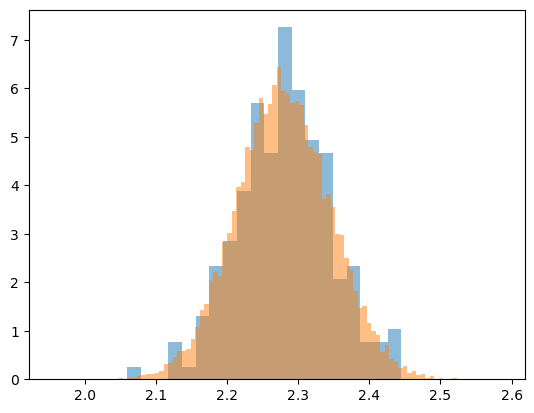

In [134]:
plt.hist(np.array(c0_samples.T[0]), alpha = 0.5, bins = 20, density = True)
plt.hist(traces2[0].posterior['c0'].values.flatten(), bins = 100, alpha = 0.5, density = True)
plt.show()

In [135]:
inputs = 1041
y_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the mean over the ensemble for each of the 1041 points for each of the 10 formulas
        f = X[m, :, :]
        y_emp[i, m] = np.mean(c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m] + X[m, 3, i] * a3_samples[:,m])
# Empirical mean over the models
y_emp

array([[ 0.4811712 ,  0.39889174,  0.44233997, ...,  0.47791899,
         0.45759473,  0.40993514],
       [ 0.75856582,  0.72271063,  0.68462475, ...,  0.73182452,
         0.73611058,  0.70939148],
       [-0.86785631, -0.90684827, -0.92814798, ..., -0.92240291,
        -0.88325038, -0.91433378],
       ...,
       [ 0.858783  ,  0.83303293,  0.87611938, ...,  0.82960742,
         0.84272872,  0.90607383],
       [ 0.16403335,  0.14555405,  0.11022603, ...,  0.18050665,
         0.17007839,  0.1747104 ],
       [ 1.22735753,  1.25518648,  1.17660522, ...,  1.33086122,
         1.20048357,  1.31789347]], shape=(1041, 10))

In [136]:
inputs = 1041
var_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the variance over the ensemble for each of the 1041 points for each of the 10 formulas
        #var_emp[i, m] = np.var((c0_samples + Phi[i, m] * a0_samples + sigma_samples - y_emp[i,m])**2), ddof = 1)
        # Assuming decorrelation between noise and parameters
        f = X[m, :, :]
        var_emp[i, m] = 1/(200-1) * np.sum((c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m] + X[m, 3, i] * a3_samples[:,m] - y_emp[i,m])**2 
                                           + sigma_samples[:,m]**2)
# Empirical variance over the models
var_emp

array([[0.41744448, 0.42080868, 0.41934066, ..., 0.4215098 , 0.41934347,
        0.4237413 ],
       [0.41917954, 0.42202254, 0.42085037, ..., 0.42357718, 0.42023315,
        0.42462595],
       [0.42110511, 0.42392426, 0.42315596, ..., 0.42512055, 0.42374564,
        0.42794286],
       ...,
       [0.41759653, 0.42164946, 0.42008035, ..., 0.42253953, 0.41988659,
        0.4240821 ],
       [0.41877854, 0.42147321, 0.4207006 , ..., 0.4234308 , 0.42048975,
        0.42478094],
       [0.41584433, 0.41908607, 0.41815912, ..., 0.41945029, 0.41804733,
        0.42104464]], shape=(1041, 10))

In [137]:
y_obs = np.tile(data['E'], (10,1)).T
y_obs

array([[ 0.67745724,  0.67745724,  0.67745724, ...,  0.67745724,
         0.67745724,  0.67745724],
       [ 1.96787596,  1.96787596,  1.96787596, ...,  1.96787596,
         1.96787596,  1.96787596],
       [-1.2712852 , -1.2712852 , -1.2712852 , ..., -1.2712852 ,
        -1.2712852 , -1.2712852 ],
       ...,
       [ 1.28468464,  1.28468464,  1.28468464, ...,  1.28468464,
         1.28468464,  1.28468464],
       [ 0.0324672 ,  0.0324672 ,  0.0324672 , ...,  0.0324672 ,
         0.0324672 ,  0.0324672 ],
       [ 2.49603244,  2.49603244,  2.49603244, ...,  2.49603244,
         2.49603244,  2.49603244]], shape=(1041, 10))

In [138]:
# Columnwise mean of the given vector, i.e. mean over the features
R = np.mean((y_obs - y_emp)**2/var_emp, axis = 0)
R

array([0.96790526, 0.963029  , 0.96543483, 0.97061208, 0.96218005,
       0.94220371, 0.96429266, 0.96394242, 0.96855855, 0.9586595 ])

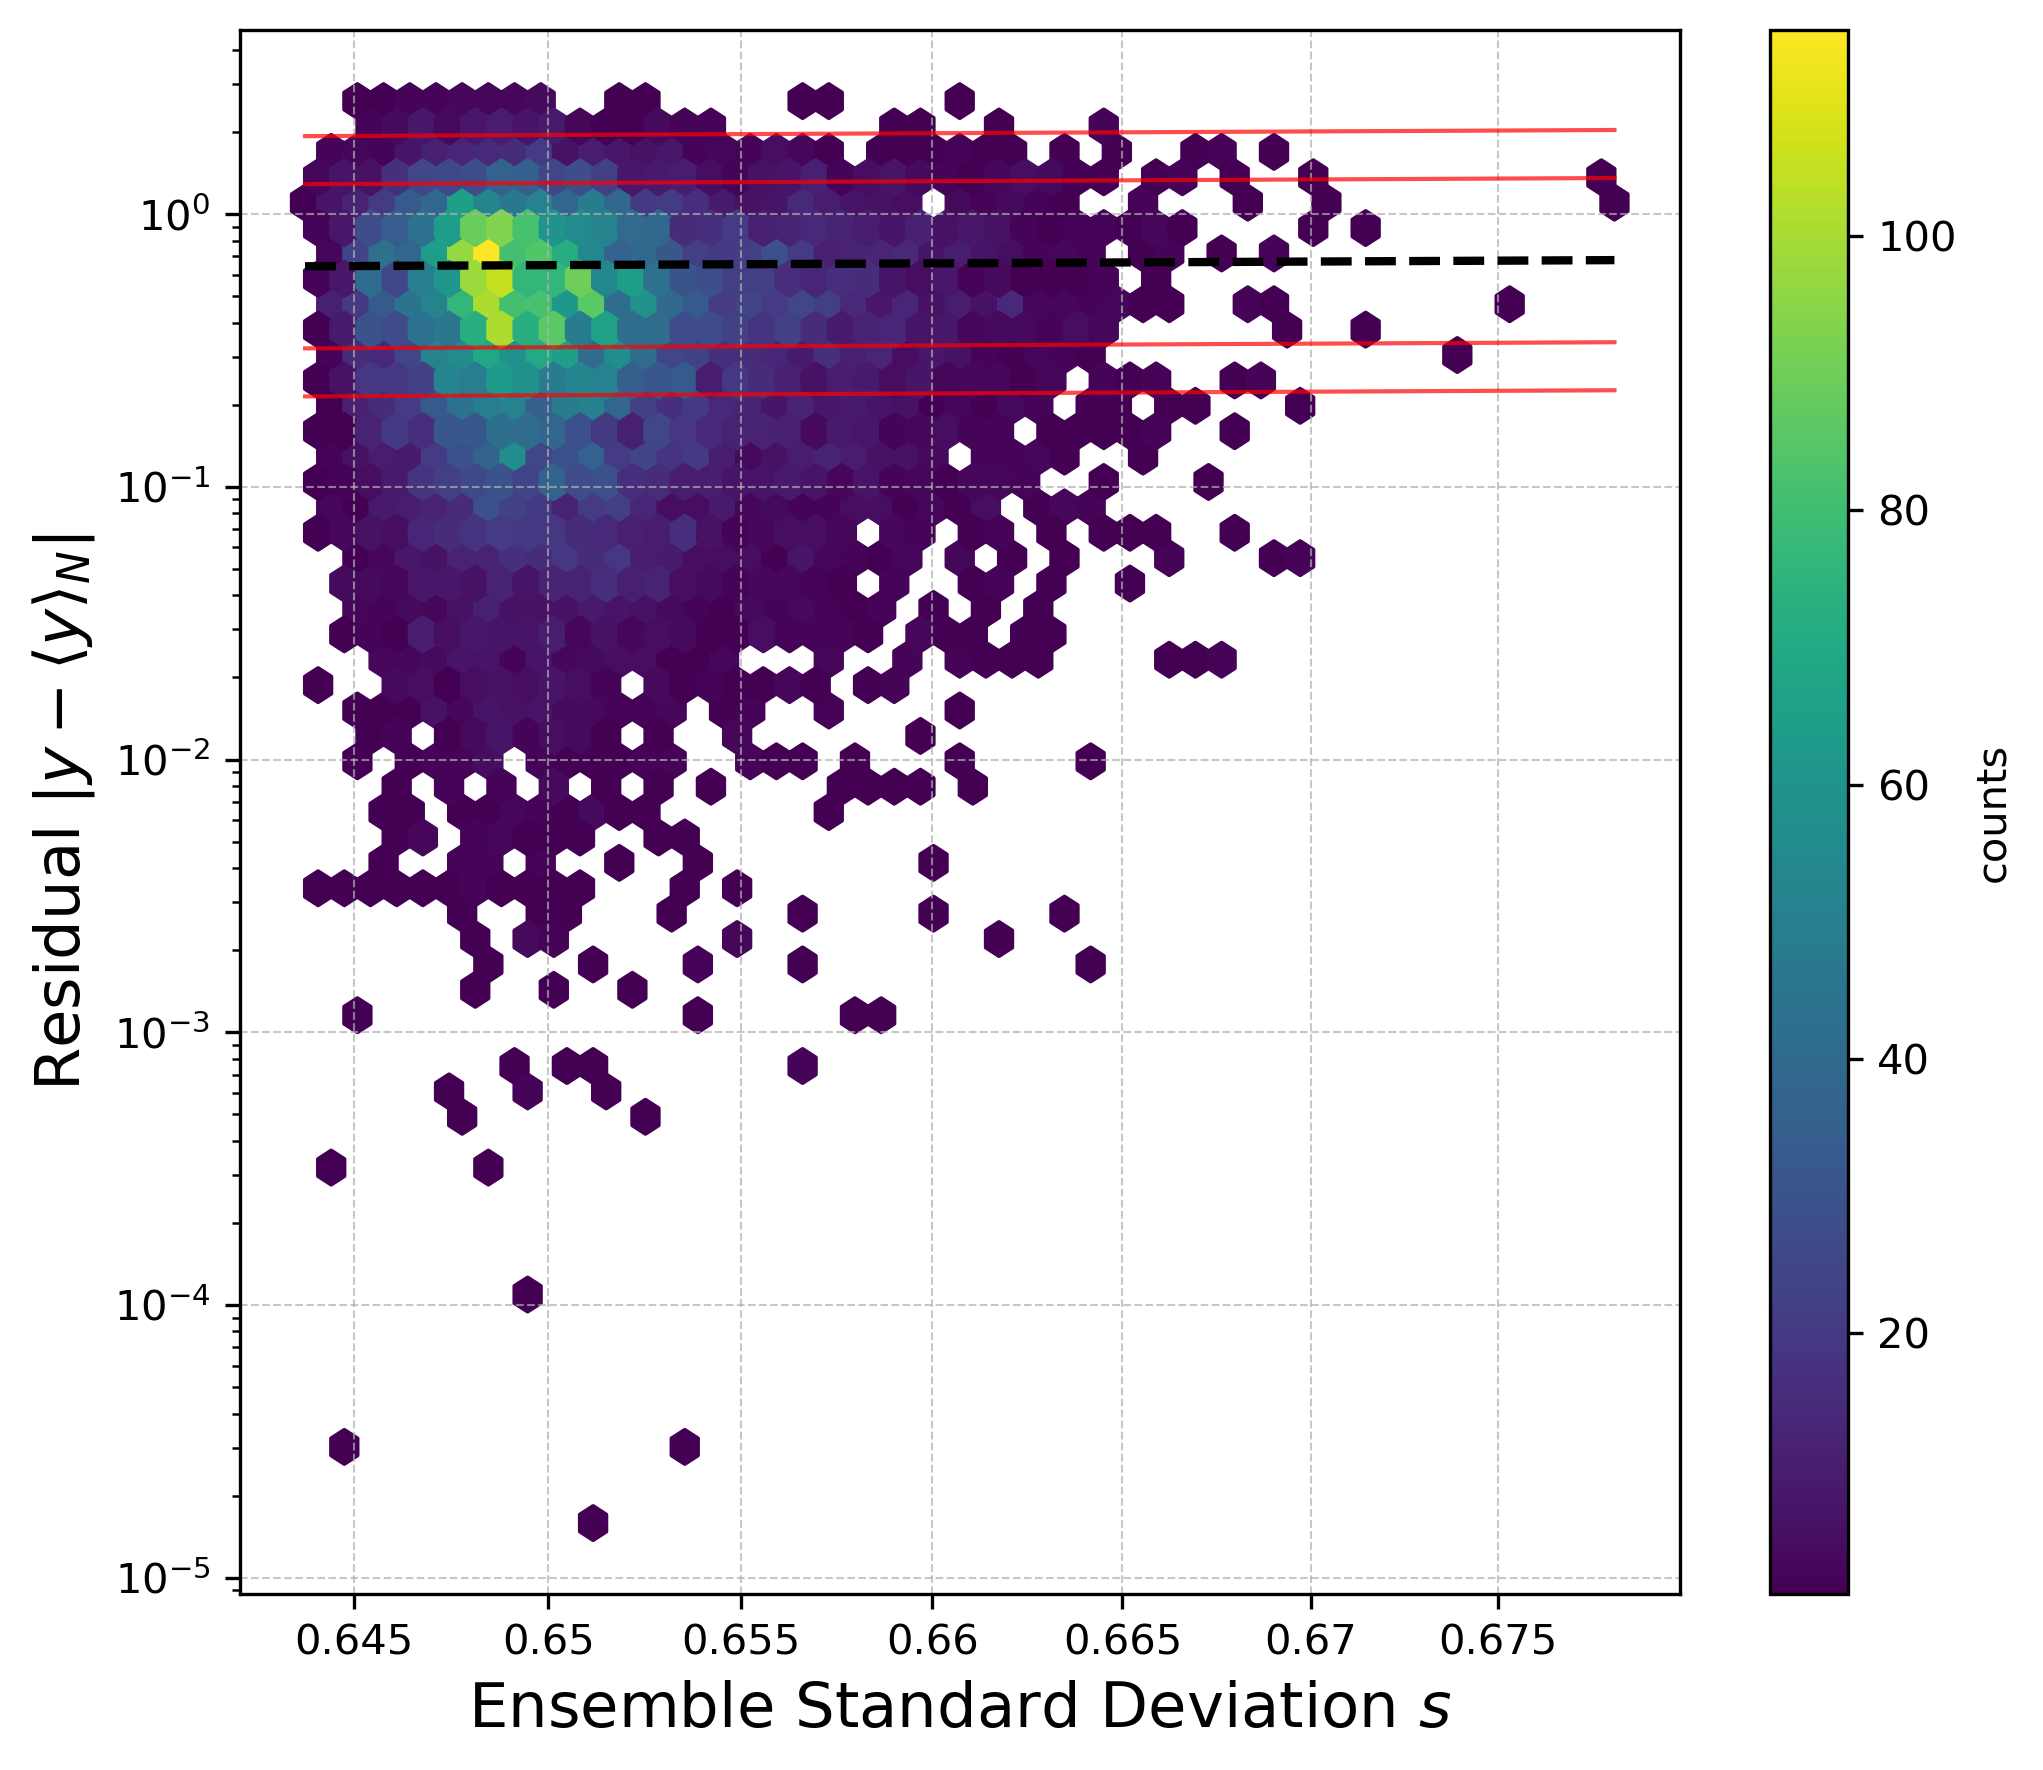

In [200]:
plt.figure(figsize=(7, 6), dpi=300)

x = np.sqrt(var_emp)  # predicted uncertainty
y = np.abs(y_obs - y_emp)  # empirical error (not squared)

# reference line y = x 
xmin, xmax = x.min(), x.max()
xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
plt.plot(xline, xline, 'k--', lw=2, label=r'$y = \hat{\sigma}$')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
# sigma lines: y = n·σ
sigma_multipliers = [1/3, 1/2, 2, 3]
for n in sigma_multipliers:
    plt.plot(xline, n * xline,
             linestyle='-',
             color='red',
             lw=1,
             alpha=0.7)

# hexbin
plt.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
           mincnt=1, cmap='viridis')
plt.colorbar(label='counts')
plt.xlabel(r'Ensemble Standard Deviation $s$', fontsize = 15)
plt.ylabel(r'Residual $|y - \langle y \rangle_N|$', fontsize = 15)
plt.xscale('log')
plt.yscale('log')
plt.xticks([0.645, 0.65, 0.655, 0.66, 0.665, 0.67, 0.675], labels = ['0.645', '0.65', '0.655', '0.66', '0.665', '0.67', '0.675']
)
plt.tight_layout()
plt.savefig('Calibration_Ea.pdf')
plt.show()

## Within Alpha

In [49]:
# Montecarlo posterior predictive values
files_ppc = [f"/home/paolo/Thesis/Na/pp_desc_dim_norm_Ea_dd4/pp2_model_{i}.nc" for i in range(10)]
ppcs = [az.from_netcdf(f) for f in files_ppc]

In [50]:
# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    # Centering of the uncertainty --> If alpha=95 then 5% of the observations will fall outside this interval and they will be split into le lowest and highest quantiles
    # the lowest quantile will be 5/2 = 2.5 and the highest quantile 100 - 2.5 = 97.5
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    # Checks whether the true value lies inside the given interval
    inside = (y_true >= lower) & (y_true <= upper)
    # Computes the mean over the inner values
    return float(np.mean(inside)), lower, upper

In [51]:
y_test = np.array(data2['E'])

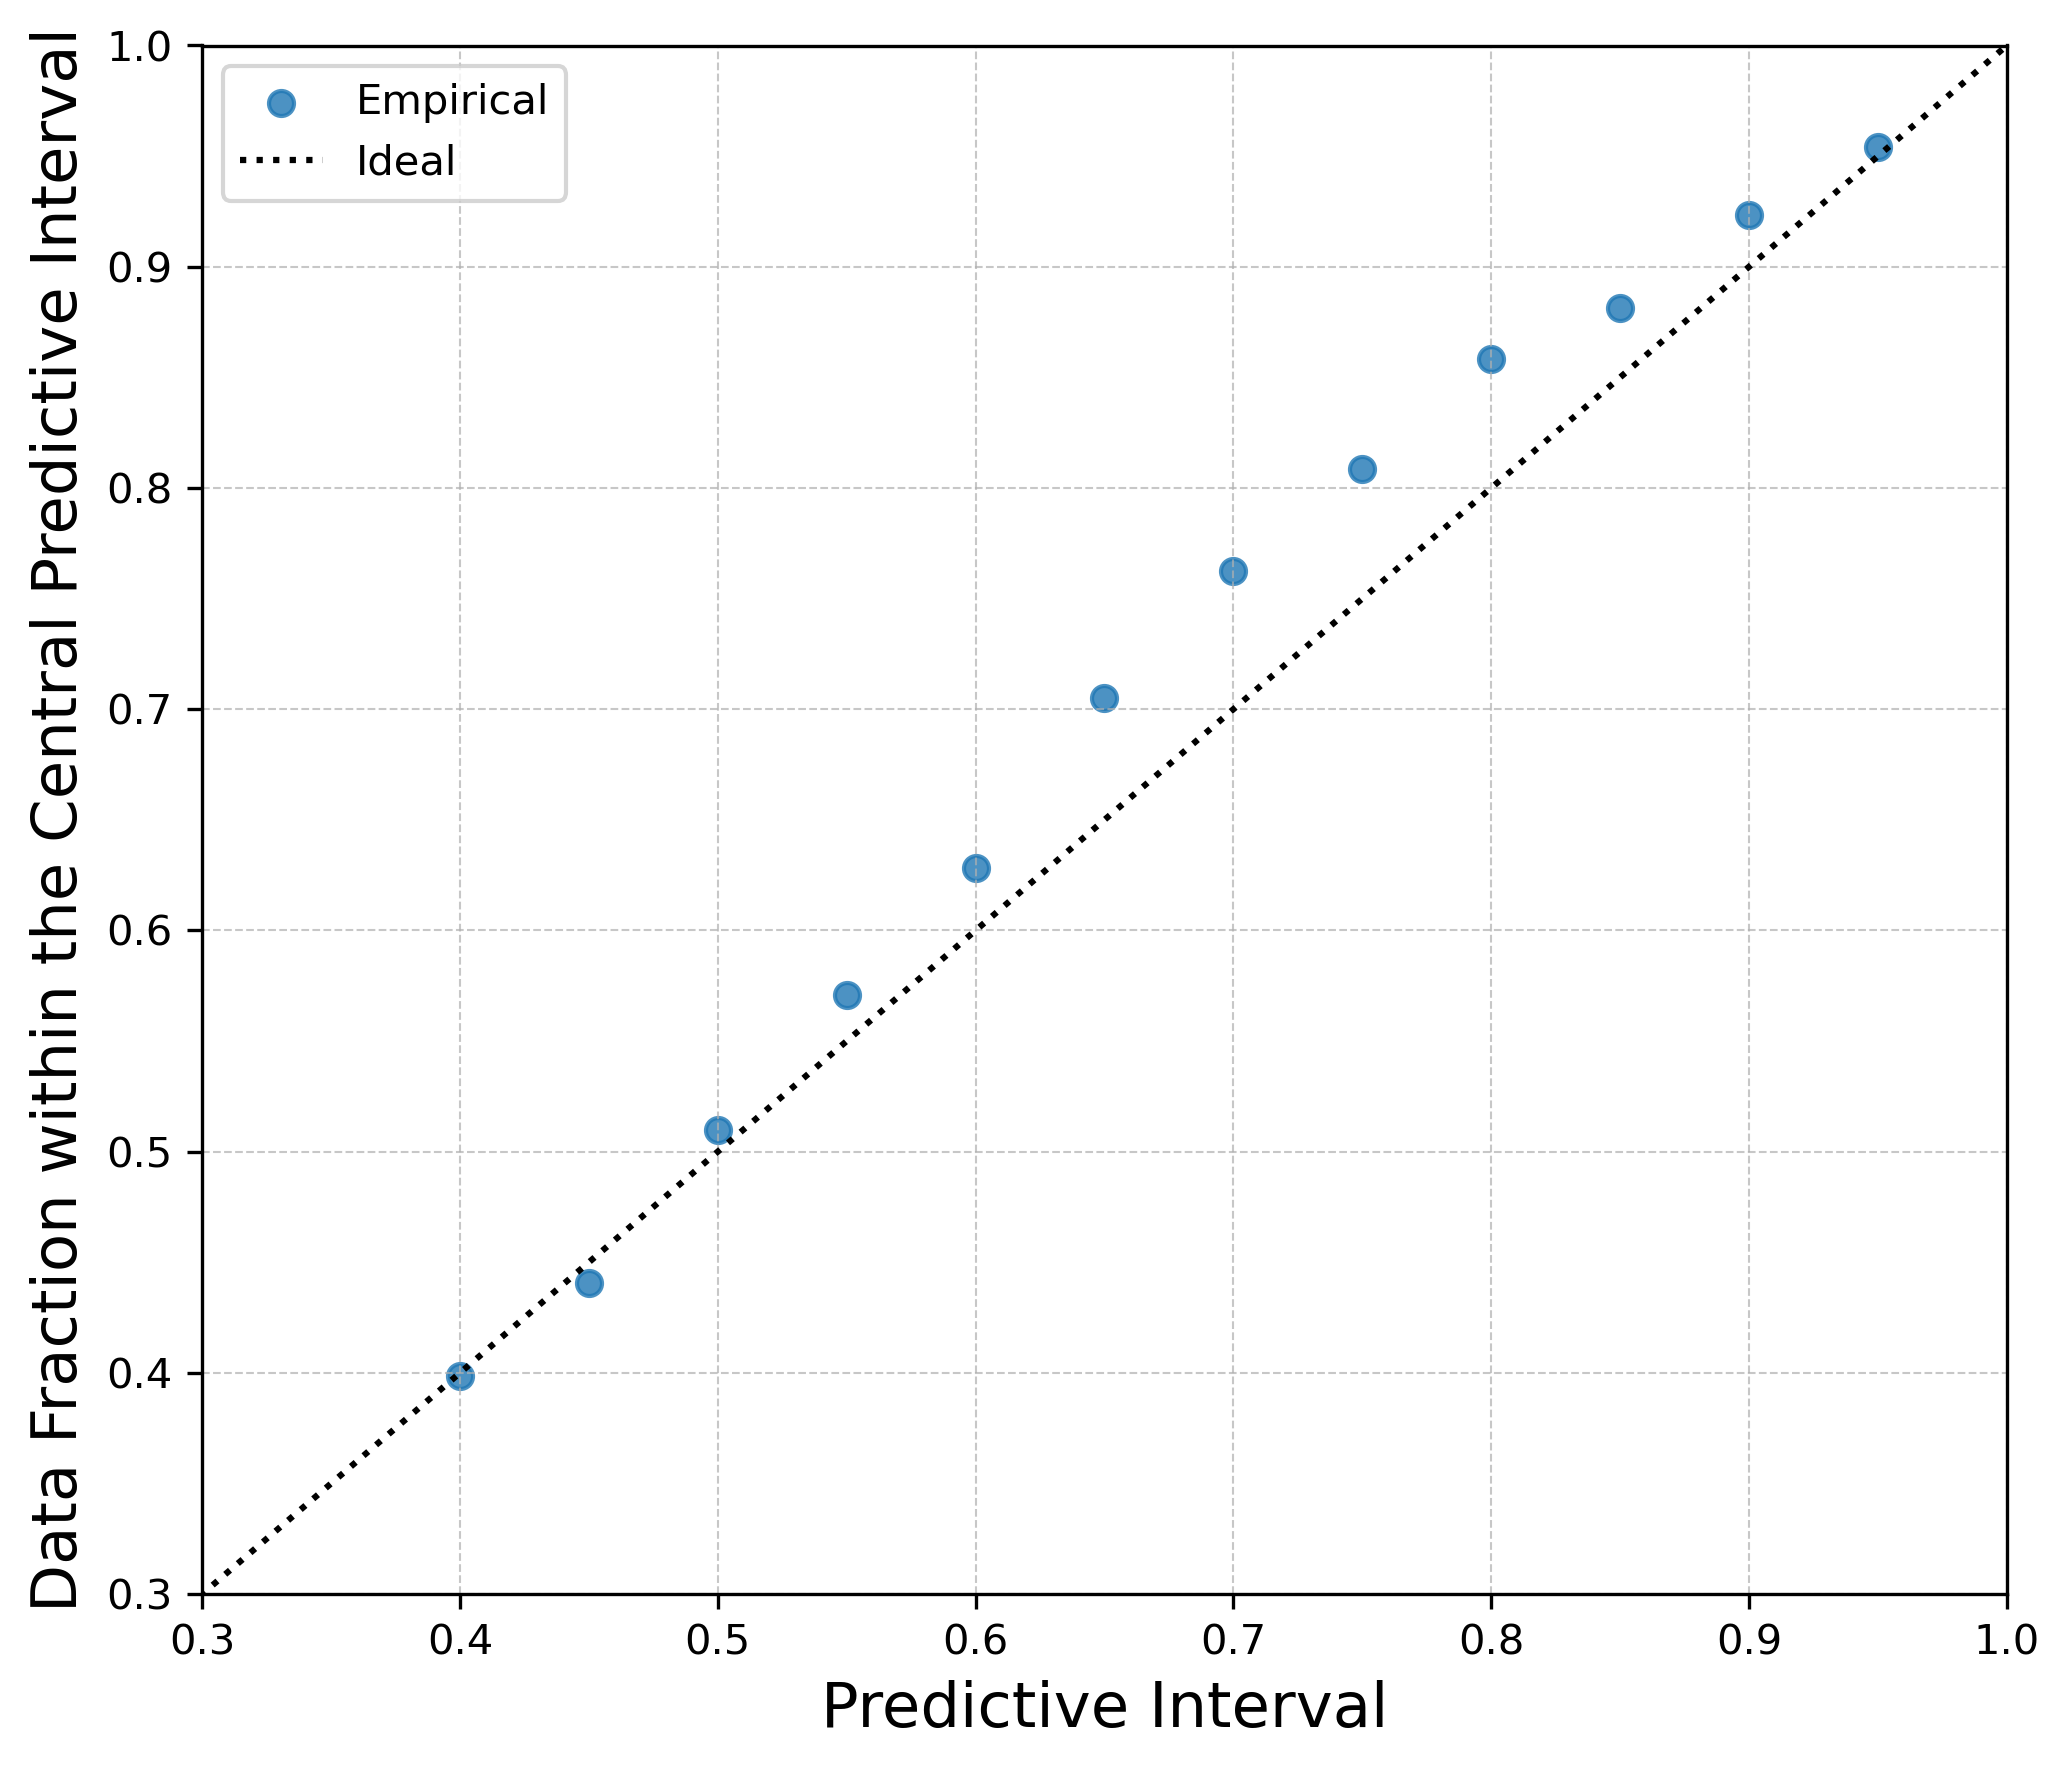

In [54]:
plt.figure(figsize=(7, 6), dpi=300)

walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[4].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.scatter(alphas,walphas, alpha=0.8, label='Empirical')
plt.ylabel('Data Fraction within the Central Predictive Interval', fontsize = 15)
plt.xlabel('Predictive Interval', fontsize = 15)
plt.plot([0,1],[0,1],linestyle=':',color='black',label='Ideal')

# Limits
plt.xlim(0.3, 1)
plt.ylim(0.3, 1)

plt.legend()
plt.tight_layout()
plt.savefig('within_Ea.pdf')
plt.show()

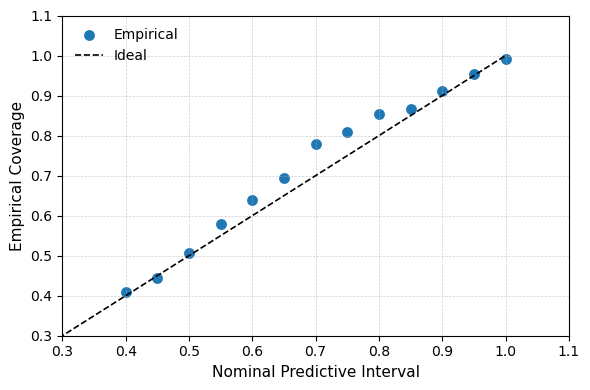

In [41]:
# Compute values
alphas = np.arange(0.4, 1.01, 0.05)
walphas = []

for alpha in alphas:
    walpha, _, _ = within_alpha(
        y_test,
        ppcs[1].posterior_predictive["y_test"].values,
        alpha=alpha,
        axis_draws=(0, 1)
    )
    walphas.append(walpha)

walphas = np.array(walphas)

# Plot
plt.figure(figsize=(6, 4))

# Main curve + points
plt.scatter(alphas, walphas, marker='o', linewidth=1.8, label='Empirical')
# Ideal calibration line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1.2, label='Ideal')

# Grid and style
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# Labels (more formal wording)
plt.xlabel('Nominal Predictive Interval', fontsize=11)
plt.ylabel('Empirical Coverage', fontsize=11)

# Limits
plt.xlim(0.3, 1.1)
plt.ylim(0.3, 1.1)

# Legend
plt.legend(frameon=False)

# Clean layout
plt.tight_layout()

# Save high-res for paper
#plt.savefig('predictive_coverage.png', dpi=300, bbox_inches='tight')

plt.show()

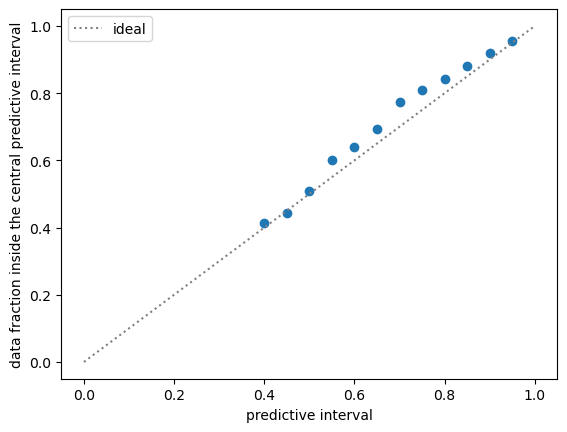

In [48]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[6].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
#plt.savefig('within.png')
plt.show()